# Adult Income: Random Forest e XGBoost para importância de características

Este notebook usa o dataset **Adult Income (UCI)** para encontrar bons candidatos a características importantes em dados tabulares.

A rede neural do trabalho principal continua sendo implementada do zero no outro notebook. Aqui usamos modelos de árvores como ferramenta auxiliar de análise:

- **Random Forest**: importância por impureza e por permutação.
- **XGBoost**: importância por ganho/feature importance, quando o pacote `xgboost` estiver instalado.
- **Importância agrupada**: junta colunas one-hot de volta na feature original, como `occupation`, `marital_status`, `sex`, etc.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
np.random.seed(SEED)

## 1. Carregamento do Adult Income

O notebook usa os arquivos oficiais `adult.data` e `adult.test`. Se eles não existirem em `data/`, são baixados automaticamente da UCI.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)

URLS = {
    'adult.data': 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',
    'adult.test': 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test',
    'adult.names': 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names',
}

COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
    'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'income'
]

NUMERIC_COLS = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
CATEGORICAL_COLS = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
TARGET_COL = 'income'

for name, url in URLS.items():
    file_path = DATA_DIR / name
    if not file_path.exists():
        print(f'Baixando {name}...')
        urlretrieve(url, file_path)

def read_adult(path, is_test=False):
    df = pd.read_csv(
        path,
        names=COLUMNS,
        sep=',',
        skipinitialspace=True,
        skiprows=1 if is_test else 0,
        keep_default_na=False,
    )
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    df[TARGET_COL] = df[TARGET_COL].str.replace('.', '', regex=False)
    return df

train_df = read_adult(DATA_DIR / 'adult.data')
test_df = read_adult(DATA_DIR / 'adult.test', is_test=True)

for df in [train_df, test_df]:
    for col in CATEGORICAL_COLS:
        df[col] = df[col].replace('?', 'Unknown')
    for col in NUMERIC_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Treino:', train_df.shape)
print('Teste :', test_df.shape)
train_df.head()

Treino: (32561, 15)
Teste : (16281, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Pré-processamento

Para comparar os modelos de árvore com a MLP, usamos o mesmo espírito de preparação:

- Removemos `education`, pois ela é redundante com `education_num`.
- Preservamos `Unknown` como categoria.
- Aplicamos one-hot encoding em variáveis categóricas.
- Mantemos um mapa entre colunas one-hot e features originais para agregar importâncias depois.

In [3]:
def encode_target(series):
    return (series.astype(str).str.strip() == '>50K').astype(int).to_numpy()

DROP_COLS = ['education']
features = [c for c in NUMERIC_COLS + CATEGORICAL_COLS if c not in DROP_COLS]

X_train_df = train_df[features].copy()
X_test_df = test_df[features].copy()
y_train = encode_target(train_df[TARGET_COL])
y_test = encode_target(test_df[TARGET_COL])

combined = pd.concat([X_train_df, X_test_df], axis=0, ignore_index=True)
combined_encoded = pd.get_dummies(combined, columns=[c for c in CATEGORICAL_COLS if c not in DROP_COLS], dtype=np.float32)

X_train = combined_encoded.iloc[:len(X_train_df)].to_numpy(dtype=np.float32)
X_test = combined_encoded.iloc[len(X_train_df):].to_numpy(dtype=np.float32)
feature_names = combined_encoded.columns.to_list()

feature_groups = {}
for original in features:
    if original in NUMERIC_COLS:
        feature_groups[original] = [feature_names.index(original)]
    else:
        prefix = original + '_'
        feature_groups[original] = [i for i, name in enumerate(feature_names) if name.startswith(prefix)]

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('Features codificadas:', len(feature_names))
print('Features originais agrupadas:', list(feature_groups.keys()))

X_train: (32561, 92)
X_test : (16281, 92)
Features codificadas: 92
Features originais agrupadas: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


## 3. Funções auxiliares

As importâncias nativas dos modelos são calculadas por coluna codificada. Para dados com one-hot encoding, isso pode fragmentar a relevância de uma feature categórica. Por isso agregamos as importâncias por feature original.

In [4]:
def evaluate_predictions(y_true, y_pred, title='Modelo'):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }
    print(title)
    display(pd.DataFrame([metrics]))
    print(classification_report(y_true, y_pred, target_names=['<=50K', '>50K'], zero_division=0))
    display(pd.DataFrame(confusion_matrix(y_true, y_pred), index=['real <=50K', 'real >50K'], columns=['pred <=50K', 'pred >50K']))
    return metrics


def aggregate_importances(importances, feature_groups, normalize=True):
    rows = []
    importances = np.asarray(importances, dtype=float)
    for group, indices in feature_groups.items():
        value = importances[indices].sum()
        rows.append({'feature': group, 'importance': value})
    df = pd.DataFrame(rows).sort_values('importance', ascending=False).reset_index(drop=True)
    if normalize and df['importance'].sum() > 0:
        df['importance'] = df['importance'] / df['importance'].sum()
    return df


def plot_top_importances(df, title, top_n=12):
    data = df.head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(data['feature'], data['importance'], color='#4C78A8')
    ax.set_title(title)
    ax.set_xlabel('Importância agregada')
    ax.set_ylabel('Feature original')
    plt.tight_layout()
    plt.show()

## 4. Random Forest

A Random Forest serve como baseline robusto para dados tabulares. Usamos `class_weight='balanced'` porque o Adult Income é desbalanceado: a classe `<=50K` aparece muito mais que `>50K`.

In [5]:
rf = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_metrics = evaluate_predictions(y_test, rf_pred, 'Random Forest')

Random Forest


,accuracy,precision,recall,f1
0,0.840857,0.626947,0.805772,0.7052


              precision    recall  f1-score   support

       <=50K       0.93      0.85      0.89     12435
        >50K       0.63      0.81      0.71      3846

    accuracy                           0.84     16281
   macro avg       0.78      0.83      0.80     16281
weighted avg       0.86      0.84      0.85     16281



,pred <=50K,pred >50K
real <=50K,10591,1844
real >50K,747,3099


,feature,importance
17,marital_status_Married-civ-spouse,0.129374
0,age,0.111533
2,education_num,0.109321
3,capital_gain,0.091521
37,relationship_Husband,0.075957
19,marital_status_Never-married,0.067106
5,hours_per_week,0.060170
1,fnlwgt,0.055038
40,relationship_Own-child,0.025430
4,capital_loss,0.024111


,feature,importance
0,marital_status,0.215284
1,relationship,0.152045
2,age,0.111533
3,education_num,0.109321
4,occupation,0.096667
5,capital_gain,0.091521
6,hours_per_week,0.060170
7,fnlwgt,0.055038
8,sex,0.031634
9,workclass,0.027988


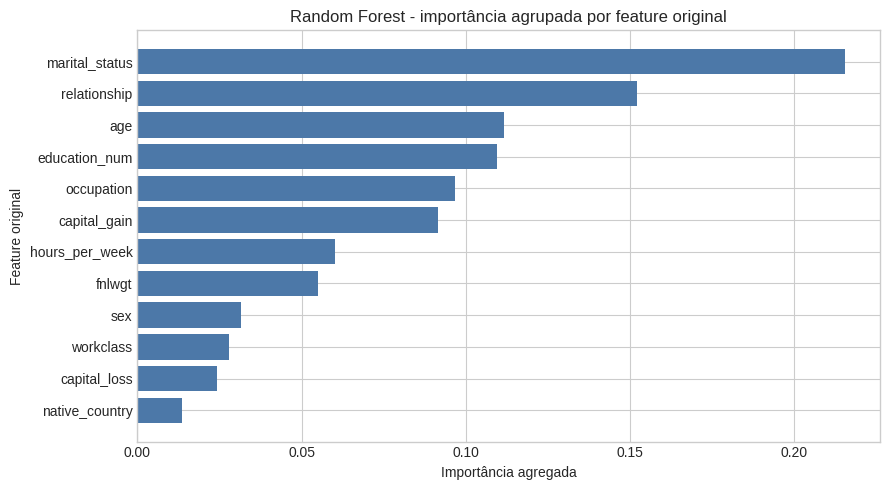

In [6]:
rf_encoded_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_,
}).sort_values('importance', ascending=False)

rf_grouped_importance = aggregate_importances(rf.feature_importances_, feature_groups)

display(rf_encoded_importance.head(15))
display(rf_grouped_importance)
plot_top_importances(rf_grouped_importance, 'Random Forest - importância agrupada por feature original')

## 5. Permutation Importance com Random Forest

A importância por impureza pode favorecer features com muitos splits possíveis. A permutation importance é uma checagem mais direta: embaralha uma feature e mede a queda no F1.

Como há one-hot encoding, fazemos a permutação por grupos de colunas da feature original.

,feature,base_f1,mean_drop_f1,std_drop_f1
0,marital_status,0.7052,0.077935,0.002334
1,capital_gain,0.7052,0.048028,0.000922
2,education_num,0.7052,0.039926,0.001746
3,age,0.7052,0.038125,0.003599
4,occupation,0.7052,0.036198,0.002849
5,relationship,0.7052,0.029601,0.002983
6,hours_per_week,0.7052,0.017776,0.002288
7,capital_loss,0.7052,0.007713,0.001230
8,workclass,0.7052,0.005444,0.001780
9,fnlwgt,0.7052,0.002238,0.001066


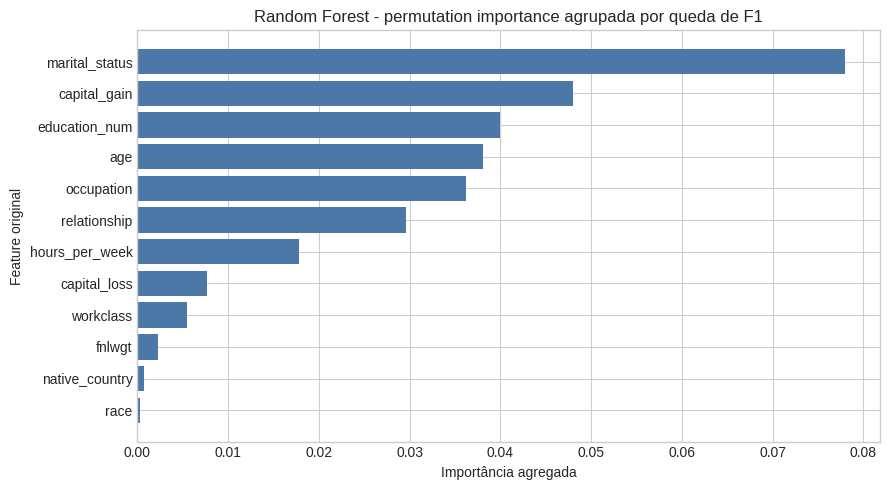

In [7]:
def grouped_permutation_importance(model, X, y, feature_groups, metric_fn=f1_score, n_repeats=5, seed=42):
    rng = np.random.default_rng(seed)
    base_pred = model.predict(X)
    base_score = metric_fn(y, base_pred, zero_division=0)
    rows = []

    for feature, indices in feature_groups.items():
        drops = []
        indices = list(indices)
        for _ in range(n_repeats):
            X_perm = X.copy()
            perm = rng.permutation(X.shape[0])
            X_perm[:, indices] = X_perm[perm][:, indices]
            perm_pred = model.predict(X_perm)
            perm_score = metric_fn(y, perm_pred, zero_division=0)
            drops.append(base_score - perm_score)
        rows.append({
            'feature': feature,
            'base_f1': base_score,
            'mean_drop_f1': float(np.mean(drops)),
            'std_drop_f1': float(np.std(drops)),
        })

    return pd.DataFrame(rows).sort_values('mean_drop_f1', ascending=False).reset_index(drop=True)

rf_perm_grouped = grouped_permutation_importance(rf, X_test, y_test, feature_groups, n_repeats=5, seed=SEED)
display(rf_perm_grouped)

plot_top_importances(
    rf_perm_grouped.rename(columns={'mean_drop_f1': 'importance'})[['feature', 'importance']],
    'Random Forest - permutation importance agrupada por queda de F1'
)

## 6. XGBoost opcional

Se `xgboost` estiver instalado, treinamos um `XGBClassifier` e agregamos as importâncias por feature original.

Caso não esteja instalado, esta seção não quebra o notebook. Para ativar depois:

```bash
python -m pip install xgboost
```

XGBoost


,accuracy,precision,recall,f1
0,0.831276,0.598849,0.865575,0.707921


              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88     12435
        >50K       0.60      0.87      0.71      3846

    accuracy                           0.83     16281
   macro avg       0.78      0.84      0.79     16281
weighted avg       0.87      0.83      0.84     16281



,pred <=50K,pred >50K
real <=50K,10205,2230
real >50K,517,3329


,feature,importance
17,marital_status_Married-civ-spouse,0.328577
37,relationship_Husband,0.126971
2,education_num,0.046906
3,capital_gain,0.041647
25,occupation_Exec-managerial,0.030821
29,occupation_Other-service,0.027210
40,relationship_Own-child,0.025122
42,relationship_Wife,0.021875
31,occupation_Prof-specialty,0.019670
0,age,0.018064


,feature,importance
0,marital_status,0.357996
1,relationship,0.190263
2,occupation,0.154347
3,native_country,0.077277
4,education_num,0.046906
5,capital_gain,0.041647
6,workclass,0.035770
7,sex,0.020105
8,race,0.019510
9,age,0.018064


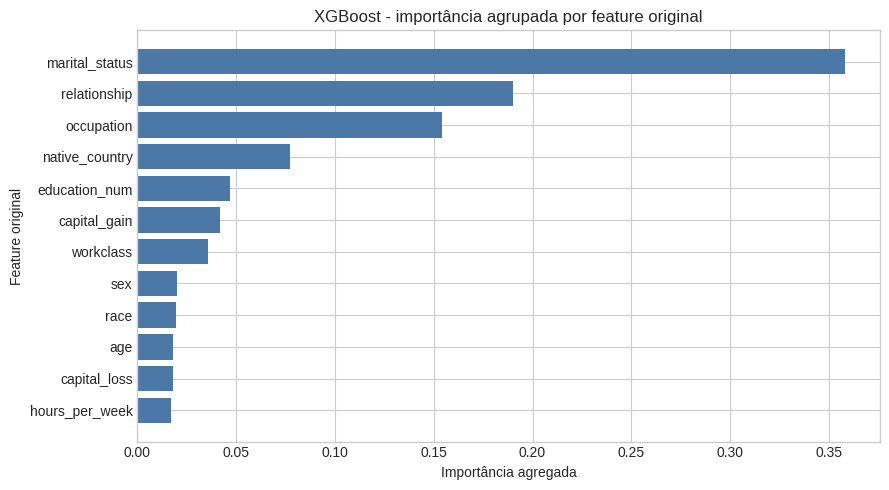

In [8]:
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ModuleNotFoundError:
    XGBOOST_AVAILABLE = False
    print('xgboost não está instalado. Pulando o treinamento com XGBoost.')

xgb = None
xgb_metrics = None
xgb_grouped_importance = None

if XGBOOST_AVAILABLE:
    scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    xgb = XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    xgb_metrics = evaluate_predictions(y_test, xgb_pred, 'XGBoost')

    xgb_grouped_importance = aggregate_importances(xgb.feature_importances_, feature_groups)
    display(pd.DataFrame({'feature': feature_names, 'importance': xgb.feature_importances_}).sort_values('importance', ascending=False).head(15))
    display(xgb_grouped_importance)
    plot_top_importances(xgb_grouped_importance, 'XGBoost - importância agrupada por feature original')

## 7. Comparação dos rankings

Esta tabela combina os rankings disponíveis. Ela é útil para escolher **candidatos a features importantes** para investigar no relatório e comparar com a interpretabilidade da MLP.

In [9]:
ranking = rf_grouped_importance.rename(columns={'importance': 'rf_impurity'}).copy()
ranking = ranking.merge(
    rf_perm_grouped[['feature', 'mean_drop_f1']].rename(columns={'mean_drop_f1': 'rf_permutation_drop_f1'}),
    on='feature',
    how='left',
)

if xgb_grouped_importance is not None:
    ranking = ranking.merge(
        xgb_grouped_importance.rename(columns={'importance': 'xgb_importance'}),
        on='feature',
        how='left',
    )
else:
    ranking['xgb_importance'] = np.nan

for col in ['rf_impurity', 'rf_permutation_drop_f1', 'xgb_importance']:
    if ranking[col].notna().any() and ranking[col].max() > 0:
        ranking[col + '_rank'] = ranking[col].rank(ascending=False, method='min')

rank_cols = [c for c in ranking.columns if c.endswith('_rank')]
ranking['mean_rank'] = ranking[rank_cols].mean(axis=1)
ranking = ranking.sort_values(['mean_rank', 'rf_permutation_drop_f1'], ascending=[True, False]).reset_index(drop=True)

display(ranking)

candidate_features = ranking.head(8)['feature'].tolist()
print('Principais candidatas a características importantes:')
for i, feature in enumerate(candidate_features, 1):
    print(f'{i}. {feature}')

,feature,rf_impurity,rf_permutation_drop_f1,xgb_importance,rf_impurity_rank,rf_permutation_drop_f1_rank,xgb_importance_rank,mean_rank
0,marital_status,0.215284,0.077935,0.357996,1.0,1.0,1.0,1.000000
1,relationship,0.152045,0.029601,0.190263,2.0,6.0,2.0,3.333333
2,education_num,0.109321,0.039926,0.046906,4.0,3.0,5.0,4.000000
3,occupation,0.096667,0.036198,0.154347,5.0,5.0,3.0,4.333333
4,capital_gain,0.091521,0.048028,0.041647,6.0,2.0,6.0,4.666667
5,age,0.111533,0.038125,0.018064,3.0,4.0,10.0,5.666667
6,hours_per_week,0.060170,0.017776,0.017089,7.0,7.0,12.0,8.666667
7,workclass,0.027988,0.005444,0.035770,10.0,9.0,7.0,8.666667
8,native_country,0.013613,0.000752,0.077277,12.0,11.0,4.0,9.000000
9,capital_loss,0.024111,0.007713,0.017902,11.0,8.0,11.0,10.000000


Principais candidatas a características importantes:
1. marital_status
2. relationship
3. education_num
4. occupation
5. capital_gain
6. age
7. hours_per_week
8. workclass


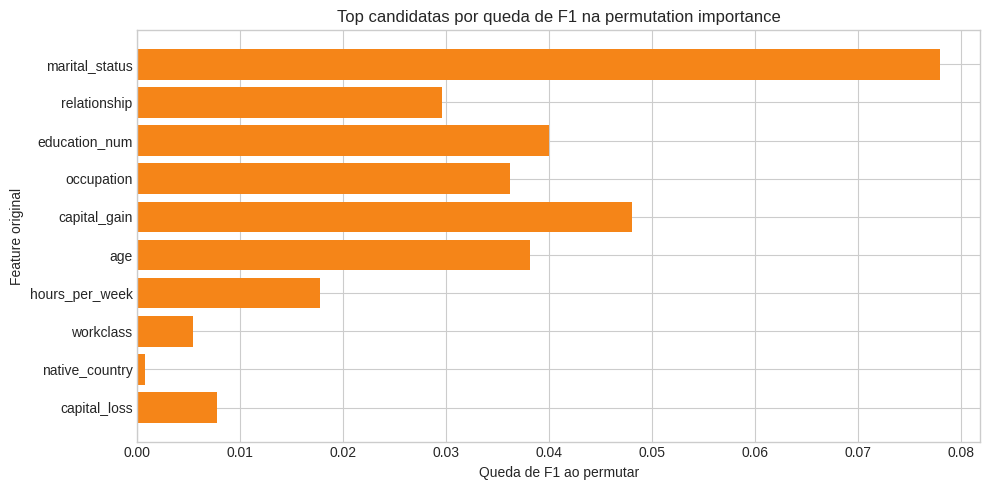

In [10]:
plot_df = ranking.head(10).copy()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_df['feature'].iloc[::-1], plot_df['rf_permutation_drop_f1'].iloc[::-1], color='#F58518')
ax.set_title('Top candidatas por queda de F1 na permutation importance')
ax.set_xlabel('Queda de F1 ao permutar')
ax.set_ylabel('Feature original')
plt.tight_layout()
plt.show()


## 9. Buscando padrões da classe de alta renda (`>50K`)

Além de ranquear features, é útil investigar diretamente **quais perfis têm maior taxa real de `>50K`** e quais perfis o modelo reconhece ou deixa passar.

Esta seção combina quatro visões:

- Taxas reais de alta renda por grupos categóricos.
- Faixas numéricas para idade, horas semanais e ganho de capital.
- Cruzamentos entre pares de variáveis importantes.
- Uma árvore pequena e interpretável para extrair regras candidatas.
- Comparação entre verdadeiros positivos e falsos negativos do melhor modelo disponível.


In [11]:

analysis_df = train_df.copy()
analysis_df['is_high_income'] = (analysis_df[TARGET_COL] == '>50K').astype(int)

analysis_df['age_bin'] = pd.cut(
    analysis_df['age'],
    bins=[16, 25, 35, 45, 55, 65, 100],
    include_lowest=True,
)
analysis_df['hours_bin'] = pd.cut(
    analysis_df['hours_per_week'],
    bins=[0, 30, 40, 50, 60, 100],
    include_lowest=True,
)
analysis_df['capital_gain_bin'] = pd.cut(
    analysis_df['capital_gain'],
    bins=[-1, 0, 1, 5000, 10000, 100000],
    labels=['0', '1', '2-5k', '5k-10k', '10k+'],
)
analysis_df['capital_loss_bin'] = pd.cut(
    analysis_df['capital_loss'],
    bins=[-1, 0, 1, 1000, 2000, 5000],
    labels=['0', '1', '2-1k', '1k-2k', '2k+'],
)


def high_income_rate_by(df, col, min_count=50):
    grouped = (
        df.groupby(col, observed=True)
        .agg(
            n=('is_high_income', 'size'),
            high_income_rate=('is_high_income', 'mean'),
        )
        .query('n >= @min_count')
        .sort_values('high_income_rate', ascending=False)
    )
    grouped['high_income_rate'] = grouped['high_income_rate'].round(4)
    return grouped

important_columns = [
    'education', 'education_num', 'marital_status', 'occupation', 'relationship',
    'sex', 'race', 'age_bin', 'hours_bin', 'capital_gain_bin', 'capital_loss_bin',
]

for col in important_columns:
    print(f'\nTaxa real de >50K por {col}')
    display(high_income_rate_by(analysis_df, col).head(12))



Taxa real de >50K por education


,n,high_income_rate
education,,
Doctorate,413,0.7409
Prof-school,576,0.7344
Masters,1723,0.5566
Bachelors,5355,0.4148
Assoc-voc,1382,0.2612
Assoc-acdm,1067,0.2484
Some-college,7291,0.1902
HS-grad,10501,0.1595
12th,433,0.0762



Taxa real de >50K por education_num


,n,high_income_rate
education_num,,
16,413,0.7409
15,576,0.7344
14,1723,0.5566
13,5355,0.4148
11,1382,0.2612
12,1067,0.2484
10,7291,0.1902
9,10501,0.1595
8,433,0.0762



Taxa real de >50K por marital_status


...

,n,high_income_rate
hours_bin,,
"(50.0, 60.0]",2533,0.4343
"(40.0, 50.0]",5938,0.3961
"(60.0, 100.0]",1110,0.3640
"(30.0, 40.0]",17735,0.2048
"(-0.001, 30.0]",5245,0.0673



Taxa real de >50K por capital_gain_bin


,n,high_income_rate
capital_gain_bin,,
10k+,770,0.9818
5k-10k,878,0.8428
0,29849,0.2065
2-5k,1064,0.1701



Taxa real de >50K por capital_loss_bin


,n,high_income_rate
capital_loss_bin,,
1k-2k,1158,0.5432
2k+,325,0.4369
0,31042,0.2277


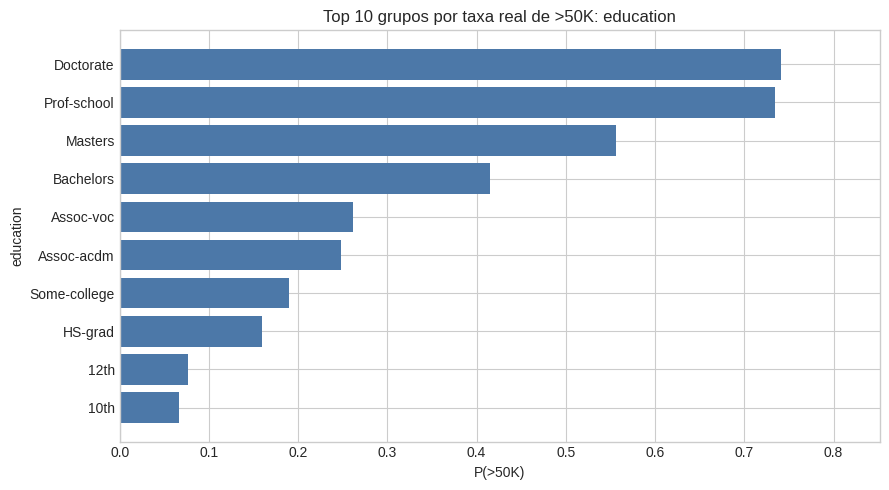

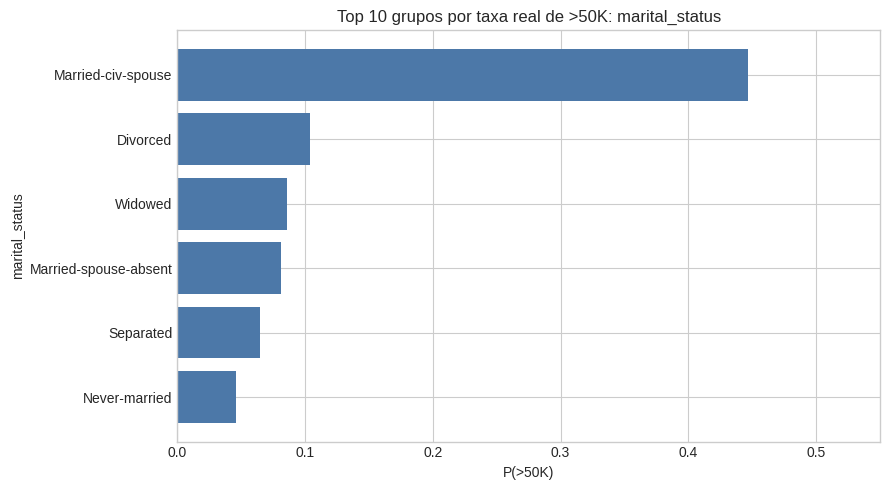

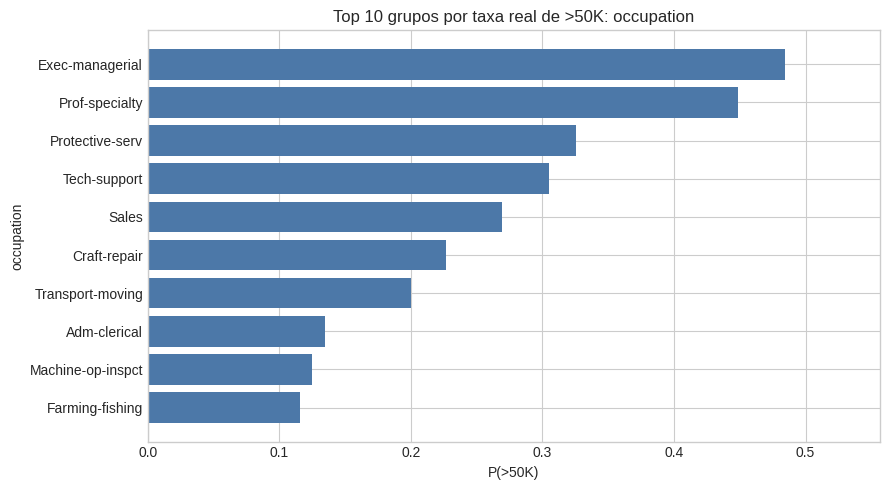

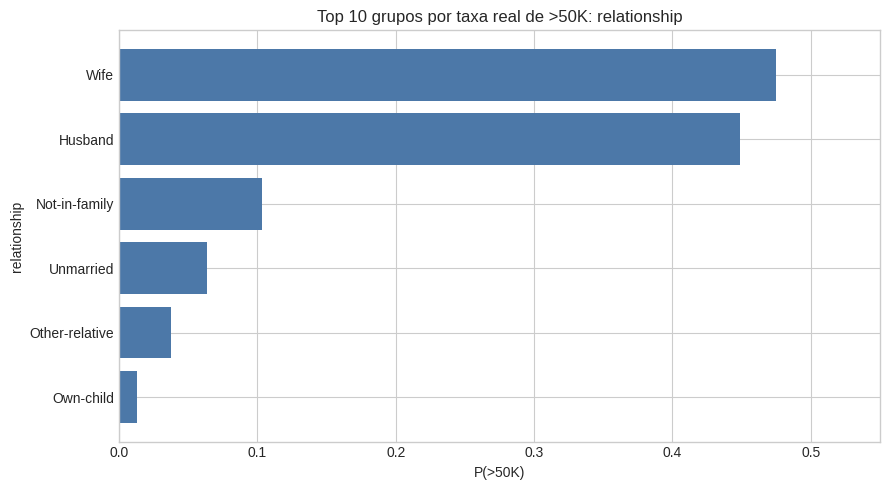

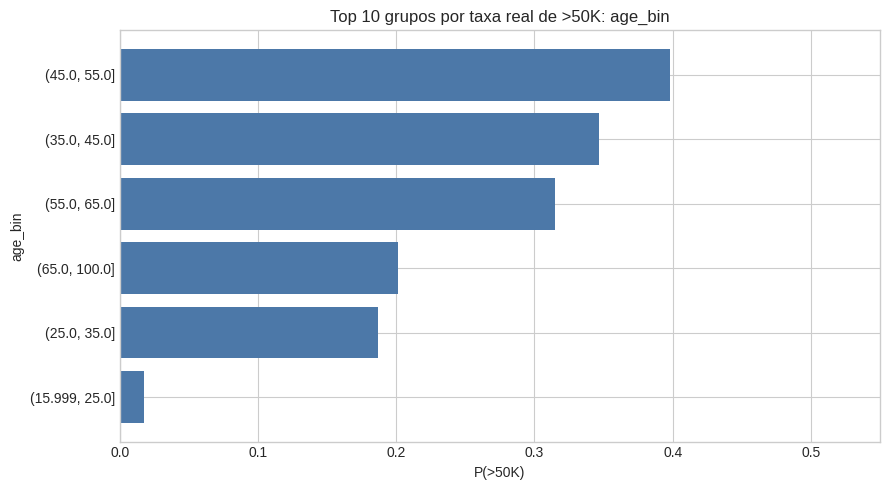

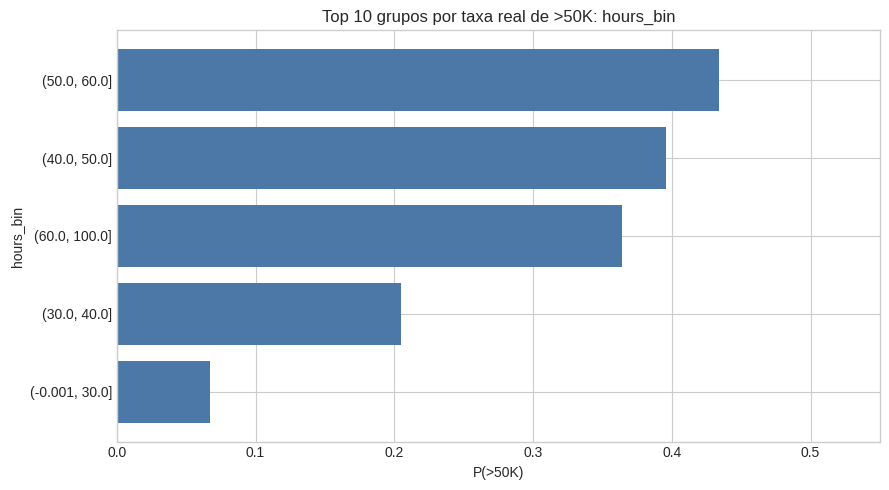

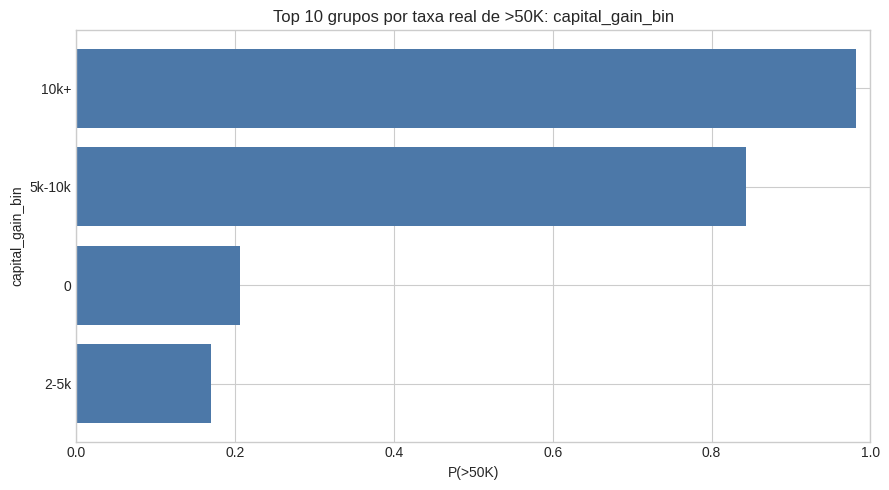

In [12]:

def plot_high_income_rate(df, col, top_n=10, min_count=50):
    rates = high_income_rate_by(df, col, min_count=min_count).head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(rates.index.astype(str), rates['high_income_rate'], color='#4C78A8')
    ax.set_title(f'Top {top_n} grupos por taxa real de >50K: {col}')
    ax.set_xlabel('P(>50K)')
    ax.set_ylabel(col)
    ax.set_xlim(0, min(1, max(0.55, rates['high_income_rate'].max() * 1.15)))
    plt.tight_layout()
    plt.show()

for col in ['education', 'marital_status', 'occupation', 'relationship', 'age_bin', 'hours_bin', 'capital_gain_bin']:
    plot_high_income_rate(analysis_df, col, top_n=10)



### 9.1 Cruzamentos entre features importantes

Os padrões de renda alta aparecem melhor em **combinações** do que em variáveis isoladas. As tabelas abaixo mostram `P(>50K)` em cruzamentos entre atributos fortes.


In [13]:

def high_income_crosstab(df, row, col, min_count=80):
    rate = pd.crosstab(df[row], df[col], values=df['is_high_income'], aggfunc='mean')
    count = pd.crosstab(df[row], df[col])
    rate = rate.where(count >= min_count)
    return rate.round(3)

cross_tabs = [
    ('education', 'marital_status'),
    ('occupation', 'marital_status'),
    ('occupation', 'education'),
    ('relationship', 'marital_status'),
    ('age_bin', 'education'),
    ('hours_bin', 'occupation'),
]

for row, col in cross_tabs:
    print(f'P(>50K): {row} x {col}')
    display(high_income_crosstab(analysis_df, row, col))


P(>50K): education x marital_status


marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
education,,,,,,,
10th,0.017,NaN,0.158,NaN,0.008,NaN,NaN
11th,0.062,NaN,0.124,NaN,0.010,NaN,NaN
12th,NaN,NaN,0.223,NaN,0.004,NaN,NaN
1st-4th,NaN,NaN,0.074,NaN,NaN,NaN,NaN
5th-6th,NaN,NaN,0.087,NaN,0.011,NaN,NaN
7th-8th,NaN,NaN,0.097,NaN,0.027,NaN,NaN
9th,NaN,NaN,0.087,NaN,0.013,NaN,NaN
Assoc-acdm,0.079,NaN,0.491,NaN,0.050,NaN,NaN
Assoc-voc,0.103,NaN,0.459,NaN,0.041,NaN,NaN


P(>50K): occupation x marital_status


marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
occupation,,,,,,,
Adm-clerical,0.032,NaN,0.441,NaN,0.021,0.020,0.043
Armed-Forces,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Craft-repair,0.097,NaN,0.325,NaN,0.040,0.058,NaN
Exec-managerial,0.237,NaN,0.682,NaN,0.140,0.202,0.204
Farming-fishing,NaN,NaN,0.176,NaN,0.017,NaN,NaN
Handlers-cleaners,0.031,NaN,0.169,NaN,0.003,NaN,NaN
Machine-op-inspct,0.014,NaN,0.241,NaN,0.009,0.012,NaN
Other-service,0.022,NaN,0.144,NaN,0.007,0.011,0.023
Priv-house-serv,NaN,NaN,NaN,NaN,NaN,NaN,NaN


P(>50K): occupation x education


...

marital_status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
relationship,,,,,,,
Husband,NaN,NaN,0.449,NaN,NaN,NaN,NaN
Not-in-family,0.129,NaN,NaN,0.118,0.091,0.107,0.086
Other-relative,0.055,NaN,0.145,NaN,0.013,NaN,NaN
Own-child,0.043,NaN,0.179,NaN,0.008,0.000,NaN
Unmarried,0.084,NaN,NaN,0.038,0.026,0.042,0.097
Wife,NaN,NaN,0.475,NaN,NaN,NaN,NaN


P(>50K): age_bin x education


education,10th,11th,12th,1st-4th,5th-6th,7th-8th,9th,Assoc-acdm,Assoc-voc,Bachelors,Doctorate,HS-grad,Masters,Preschool,Prof-school,Some-college
age_bin,,,,,,,,,,,,,,,,
"(15.999, 25.0]",0.000,0.009,0.015,NaN,NaN,NaN,0.000,0.036,0.036,0.047,NaN,0.012,NaN,NaN,NaN,0.015
"(25.0, 35.0]",0.026,0.044,0.044,NaN,NaN,0.019,0.027,0.178,0.185,0.343,NaN,0.110,0.399,NaN,0.540,0.155
"(35.0, 45.0]",0.109,0.102,NaN,NaN,NaN,0.091,0.094,0.351,0.346,0.527,0.757,0.209,0.595,NaN,0.842,0.300
"(45.0, 55.0]",0.145,0.145,NaN,NaN,NaN,0.058,0.060,0.388,0.376,0.591,0.852,0.288,0.695,NaN,0.835,0.369
"(55.0, 65.0]",0.168,0.110,NaN,NaN,NaN,0.096,0.099,NaN,0.430,0.528,NaN,0.232,0.539,NaN,NaN,0.341
"(65.0, 100.0]",NaN,NaN,NaN,NaN,NaN,0.054,NaN,NaN,NaN,0.407,NaN,0.122,NaN,NaN,NaN,0.223


P(>50K): hours_bin x occupation


occupation,Adm-clerical,Armed-Forces,Craft-repair,Exec-managerial,Farming-fishing,Handlers-cleaners,Machine-op-inspct,Other-service,Priv-house-serv,Prof-specialty,Protective-serv,Sales,Tech-support,Transport-moving,Unknown
hours_bin,,,,,,,,,,,,,,,
"(-0.001, 30.0]",0.060,NaN,0.035,0.212,0.035,0.014,0.015,0.015,NaN,0.193,NaN,0.051,0.185,0.069,0.075
"(30.0, 40.0]",0.131,NaN,0.202,0.397,0.079,0.069,0.113,0.041,NaN,0.414,0.308,0.233,0.296,0.153,0.096
"(40.0, 50.0]",0.245,NaN,0.317,0.590,0.129,0.093,0.206,0.094,NaN,0.568,0.395,0.404,0.430,0.278,0.239
"(50.0, 60.0]",0.245,NaN,0.322,0.628,0.232,NaN,NaN,0.181,NaN,0.583,NaN,0.447,NaN,0.278,NaN
"(60.0, 100.0]",NaN,NaN,0.297,0.568,0.158,NaN,NaN,NaN,NaN,0.556,NaN,0.463,NaN,0.319,NaN



### 9.2 Árvore pequena para extrair regras candidatas

A árvore abaixo não é usada como melhor classificador. Ela é propositalmente rasa para gerar regras legíveis que ajudam a descrever padrões de alta renda.


|--- marital_status_Married-civ-spouse <= 0.50
|   |--- capital_gain <= 7073.50
|   |   |--- education_num <= 12.50
|   |   |   |--- hours_per_week <= 40.50
|   |   |   |   |--- class: 0
|   |   |   |--- hours_per_week >  40.50
|   |   |   |   |--- class: 0
|   |   |--- education_num >  12.50
|   |   |   |--- hours_per_week <= 43.50
|   |   |   |   |--- class: 0
|   |   |   |--- hours_per_week >  43.50
|   |   |   |   |--- class: 0
|   |--- capital_gain >  7073.50
|   |   |--- education_num <= 12.50
|   |   |   |--- class: 1
|   |   |--- education_num >  12.50
|   |   |   |--- class: 1
|--- marital_status_Married-civ-spouse >  0.50
|   |--- education_num <= 12.50
|   |   |--- capital_gain <= 5095.50
|   |   |   |--- education_num <= 8.50
|   |   |   |   |--- class: 0
|   |   |   |--- education_num >  8.50
|   |   |   |   |--- class: 0
|   |   |--- capital_gain >  5095.50
|   |   |   |--- age <= 54.50
|   |   |   |   |--- class: 1
|   |   |   |--- age >  54.50
|   |   |   |   |--- class

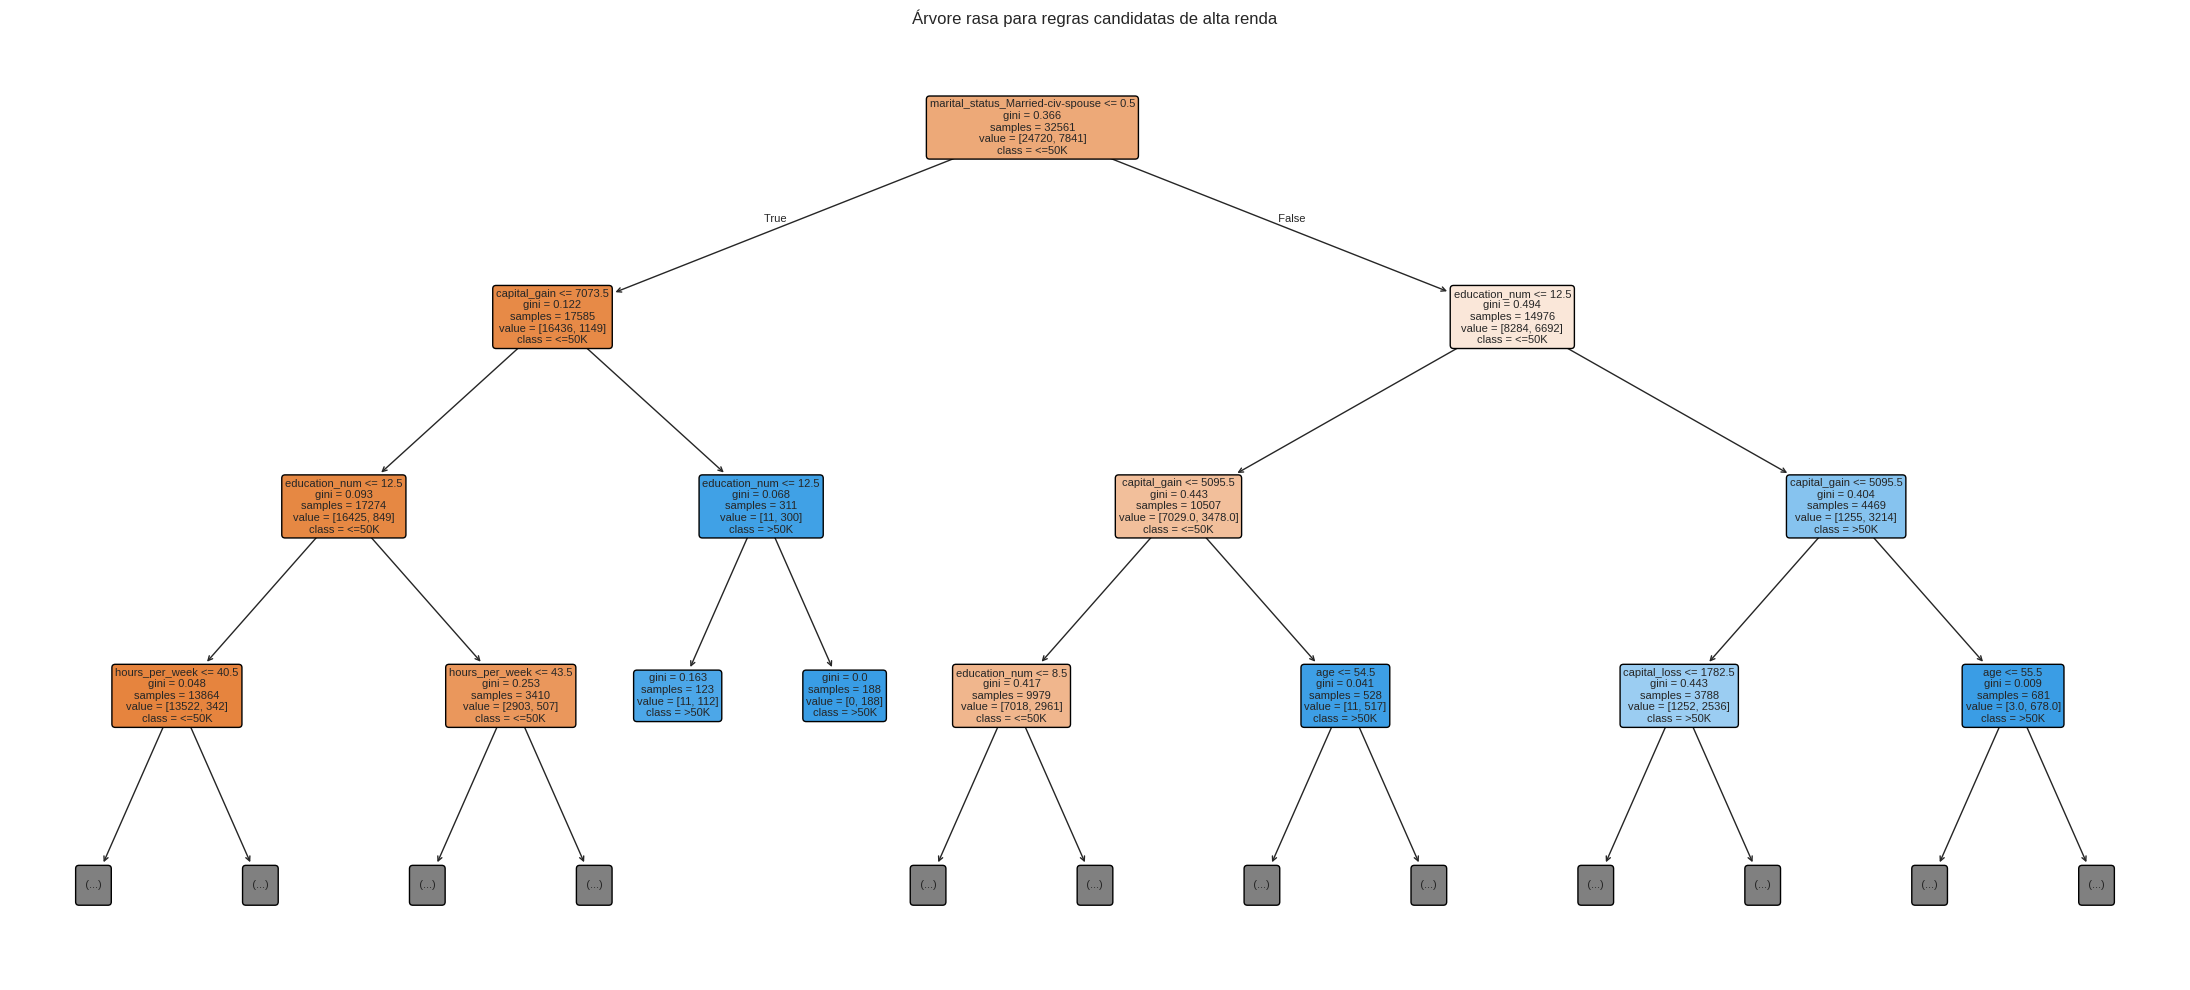

In [14]:

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

rule_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=120,
    random_state=SEED,
)
rule_tree.fit(X_train, y_train)

rules = export_text(rule_tree, feature_names=feature_names, max_depth=4)
print(rules)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    rule_tree,
    feature_names=feature_names,
    class_names=['<=50K', '>50K'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
ax.set_title('Árvore rasa para regras candidatas de alta renda')
plt.tight_layout()
plt.show()



### 9.3 Verdadeiros positivos vs falsos negativos

Para entender o padrão da classe `>50K`, comparamos:

- **TP**: casos `>50K` que o modelo reconheceu corretamente.
- **FN**: casos `>50K` que o modelo classificou como `<=50K`.

Essa comparação mostra quais perfis de alta renda são fáceis ou difíceis para o modelo.


In [15]:

if XGBOOST_AVAILABLE and xgb is not None:
    pattern_model = xgb
    pattern_model_name = 'XGBoost'
else:
    pattern_model = rf
    pattern_model_name = 'Random Forest'

pattern_pred = pattern_model.predict(X_test)
test_analysis_df = test_df.copy()
test_analysis_df['is_high_income'] = (test_analysis_df[TARGET_COL] == '>50K').astype(int)
test_analysis_df['prediction'] = pattern_pred
test_analysis_df['prediction_label'] = np.where(pattern_pred == 1, '>50K', '<=50K')

tp_df = test_analysis_df[(test_analysis_df['is_high_income'] == 1) & (test_analysis_df['prediction'] == 1)].copy()
fn_df = test_analysis_df[(test_analysis_df['is_high_income'] == 1) & (test_analysis_df['prediction'] == 0)].copy()

print(f'Modelo usado na comparação: {pattern_model_name}')
print(f'TP (>50K reconhecidos): {len(tp_df)}')
print(f'FN (>50K perdidos): {len(fn_df)}')

numeric_comparison = pd.DataFrame({
    'TP_mean': tp_df[NUMERIC_COLS].mean(),
    'FN_mean': fn_df[NUMERIC_COLS].mean(),
    'difference_TP_minus_FN': tp_df[NUMERIC_COLS].mean() - fn_df[NUMERIC_COLS].mean(),
}).round(2)

display(numeric_comparison)


Modelo usado na comparação: XGBoost
TP (>50K reconhecidos): 3329
FN (>50K perdidos): 517


,TP_mean,FN_mean,difference_TP_minus_FN
age,44.59,42.62,1.97
fnlwgt,190583.41,181926.93,8656.48
education_num,11.87,9.72,2.15
capital_gain,4737.26,114.42,4622.84
capital_loss,214.89,33.64,181.25
hours_per_week,45.82,42.81,3.00


In [16]:

def compare_category_distribution(tp_df, fn_df, col, top_n=8):
    tp_dist = tp_df[col].value_counts(normalize=True).rename('TP_share')
    fn_dist = fn_df[col].value_counts(normalize=True).rename('FN_share')
    comparison = pd.concat([tp_dist, fn_dist], axis=1).fillna(0)
    comparison['TP_minus_FN'] = comparison['TP_share'] - comparison['FN_share']
    comparison = comparison.reindex(comparison['TP_minus_FN'].abs().sort_values(ascending=False).index)
    return comparison.head(top_n).round(4)

for col in ['education', 'marital_status', 'occupation', 'relationship', 'sex', 'race', 'native_country']:
    print(f'Distribuição em TP vs FN: {col}')
    display(compare_category_distribution(tp_df, fn_df, col))


Distribuição em TP vs FN: education


,TP_share,FN_share,TP_minus_FN
education,,,
HS-grad,0.1926,0.3617,-0.1692
Bachelors,0.3046,0.1509,0.1537
Masters,0.1418,0.0542,0.0876
Prof-school,0.0580,0.0019,0.0560
10th,0.0012,0.0406,-0.0394
Doctorate,0.0369,0.0039,0.0331
11th,0.0039,0.0368,-0.0328
7th-8th,0.0021,0.0290,-0.0269


Distribuição em TP vs FN: marital_status


,TP_share,FN_share,TP_minus_FN
marital_status,,,
Married-civ-spouse,0.9048,0.5416,0.3632
Never-married,0.0384,0.2205,-0.1821
Divorced,0.0388,0.1528,-0.1141
Separated,0.0051,0.0309,-0.0258
Widowed,0.0078,0.0329,-0.0251
Married-spouse-absent,0.0039,0.0213,-0.0174
Married-AF-spouse,0.0012,0.0000,0.0012


Distribuição em TP vs FN: occupation


...

,TP_share,FN_share,TP_minus_FN
sex,,,
Female,0.1355,0.2689,-0.1334
Male,0.8645,0.7311,0.1334


Distribuição em TP vs FN: race


,TP_share,FN_share,TP_minus_FN
race,,,
White,0.9114,0.8820,0.0294
Black,0.0445,0.0600,-0.0155
Asian-Pac-Islander,0.0330,0.0445,-0.0114
Other,0.0060,0.0097,-0.0037
Amer-Indian-Eskimo,0.0051,0.0039,0.0012


Distribuição em TP vs FN: native_country


,TP_share,FN_share,TP_minus_FN
native_country,,,
United-States,0.9201,0.8897,0.0303
Mexico,0.0024,0.0116,-0.0092
Portugal,0.0009,0.0097,-0.0088
Unknown,0.0183,0.0251,-0.0068
Ireland,0.0009,0.0058,-0.0049
Iran,0.0006,0.0039,-0.0033
Jamaica,0.0009,0.0039,-0.0030
Canada,0.0066,0.0039,0.0027


In [17]:

summary_patterns = pd.DataFrame({
    'evidence': [
        'Maiores taxas reais por grupo',
        'Permutation importance / árvores',
        'Regras da árvore rasa',
        'Comparação TP vs FN',
    ],
    'candidate_pattern': [
        'Educação alta, casamento Married-civ-spouse, ocupações gerenciais/especializadas e capital_gain positivo tendem a concentrar >50K.',
        'marital_status, capital_gain, education_num, age, occupation e relationship aparecem consistentemente como fortes.',
        'Splits envolvendo capital_gain, marital_status, education_num e relationship surgem cedo na árvore interpretável.',
        'Casos de >50K reconhecidos tendem a ter maior capital_gain, education_num, idade/hours_per_week e categorias ocupacionais mais concentradas.',
    ],
})

display(summary_patterns)


,evidence,candidate_pattern
0,Maiores taxas reais por grupo,"Educação alta, casamento Married-civ-spouse, o..."
1,Permutation importance / árvores,"marital_status, capital_gain, education_num, a..."
2,Regras da árvore rasa,"Splits envolvendo capital_gain, marital_status..."
3,Comparação TP vs FN,Casos de >50K reconhecidos tendem a ter maior ...



## 10. Experimento de ablação: `is_married_civ_spouse` sem `relationship`

Hipótese: `relationship` é parcialmente redundante com `marital_status`, e a maior parte do sinal de estado civil pode estar concentrada em `Married-civ-spouse`.

Neste experimento:

- Removemos `relationship`.
- Removemos o one-hot completo de `marital_status`.
- Criamos apenas uma feature binária: `is_married_civ_spouse`.
- Treinamos Random Forest e XGBoost opcional no mesmo split oficial do Adult Income.
- Comparamos desempenho e importância das features com o modelo anterior.


In [18]:

def build_encoded_dataset_variant(train_df, test_df, use_married_binary=False, drop_original_cols=None):
    drop_original_cols = set(drop_original_cols or [])
    train_variant = train_df.copy()
    test_variant = test_df.copy()

    numeric_cols = list(NUMERIC_COLS)
    categorical_cols = list(CATEGORICAL_COLS)

    if use_married_binary:
        train_variant['is_married_civ_spouse'] = (train_variant['marital_status'] == 'Married-civ-spouse').astype(np.float32)
        test_variant['is_married_civ_spouse'] = (test_variant['marital_status'] == 'Married-civ-spouse').astype(np.float32)
        numeric_cols = numeric_cols + ['is_married_civ_spouse']
        drop_original_cols.add('marital_status')

    numeric_cols = [c for c in numeric_cols if c not in drop_original_cols]
    categorical_cols = [c for c in categorical_cols if c not in drop_original_cols]

    selected_features = numeric_cols + categorical_cols
    X_train_variant_df = train_variant[selected_features].copy()
    X_test_variant_df = test_variant[selected_features].copy()

    combined = pd.concat([X_train_variant_df, X_test_variant_df], axis=0, ignore_index=True)
    combined_encoded = pd.get_dummies(combined, columns=categorical_cols, dtype=np.float32)

    X_train_variant = combined_encoded.iloc[:len(X_train_variant_df)].to_numpy(dtype=np.float32)
    X_test_variant = combined_encoded.iloc[len(X_train_variant_df):].to_numpy(dtype=np.float32)
    variant_feature_names = combined_encoded.columns.to_list()

    variant_feature_groups = {}
    for original in selected_features:
        if original in numeric_cols:
            variant_feature_groups[original] = [variant_feature_names.index(original)]
        else:
            prefix = original + '_'
            variant_feature_groups[original] = [i for i, name in enumerate(variant_feature_names) if name.startswith(prefix)]

    return X_train_variant, X_test_variant, variant_feature_names, variant_feature_groups, selected_features

X_train_married, X_test_married, married_feature_names, married_feature_groups, married_selected_features = build_encoded_dataset_variant(
    train_df,
    test_df,
    use_married_binary=True,
    drop_original_cols={'education', 'relationship'},
)

print('Features originais usadas na variante:')
print(married_selected_features)
print('X_train variante:', X_train_married.shape)
print('X_test variante :', X_test_married.shape)
print('Features agrupadas:', list(married_feature_groups.keys()))


Features originais usadas na variante:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'is_married_civ_spouse', 'workclass', 'occupation', 'race', 'sex', 'native_country']
X_train variante: (32561, 80)
X_test variante : (16281, 80)
Features agrupadas: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'is_married_civ_spouse', 'workclass', 'occupation', 'race', 'sex', 'native_country']


Random Forest - is_married_civ_spouse sem relationship


,accuracy,precision,recall,f1
0,0.841533,0.628921,0.802912,0.705345


              precision    recall  f1-score   support

       <=50K       0.93      0.85      0.89     12435
        >50K       0.63      0.80      0.71      3846

    accuracy                           0.84     16281
   macro avg       0.78      0.83      0.80     16281
weighted avg       0.86      0.84      0.85     16281



,pred <=50K,pred >50K
real <=50K,10613,1822
real >50K,758,3088


,feature,importance
0,is_married_civ_spouse,0.234507
1,age,0.151777
2,education_num,0.120706
3,occupation,0.111469
4,capital_gain,0.101874
5,hours_per_week,0.071416
6,fnlwgt,0.060720
7,sex,0.059189
8,workclass,0.031189
9,capital_loss,0.029100


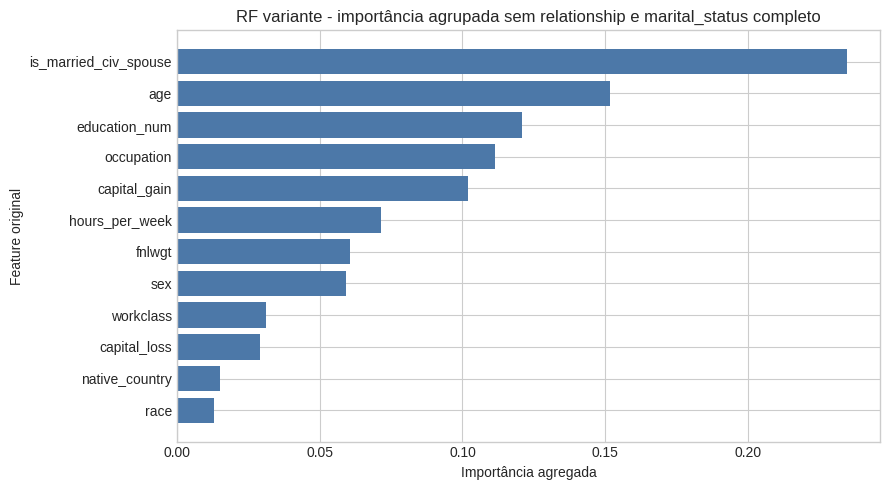

In [19]:

rf_married = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

rf_married.fit(X_train_married, y_train)
rf_married_pred = rf_married.predict(X_test_married)
rf_married_metrics = evaluate_predictions(
    y_test,
    rf_married_pred,
    'Random Forest - is_married_civ_spouse sem relationship',
)

rf_married_grouped_importance = aggregate_importances(rf_married.feature_importances_, married_feature_groups)
display(rf_married_grouped_importance)
plot_top_importances(
    rf_married_grouped_importance,
    'RF variante - importância agrupada sem relationship e marital_status completo',
)


,feature,base_f1,mean_drop_f1,std_drop_f1
0,is_married_civ_spouse,0.705345,0.146028,0.004786
1,capital_gain,0.705345,0.054198,0.000945
2,age,0.705345,0.051005,0.002570
3,education_num,0.705345,0.041851,0.003158
4,occupation,0.705345,0.037019,0.001869
5,hours_per_week,0.705345,0.020848,0.003044
6,capital_loss,0.705345,0.008502,0.001250
7,workclass,0.705345,0.005985,0.000615
8,sex,0.705345,0.004484,0.001656
9,fnlwgt,0.705345,0.003538,0.000587


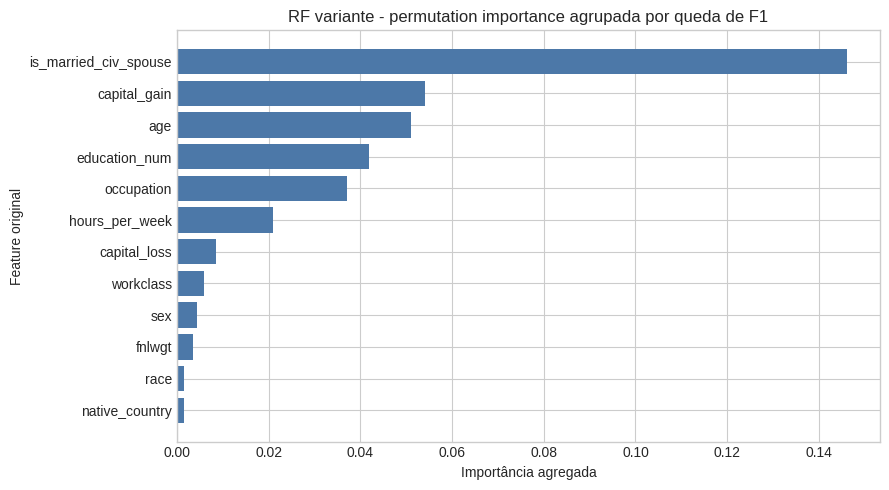

In [20]:

rf_married_perm_grouped = grouped_permutation_importance(
    rf_married,
    X_test_married,
    y_test,
    married_feature_groups,
    n_repeats=5,
    seed=SEED,
)

display(rf_married_perm_grouped)
plot_top_importances(
    rf_married_perm_grouped.rename(columns={'mean_drop_f1': 'importance'})[['feature', 'importance']],
    'RF variante - permutation importance agrupada por queda de F1',
)


XGBoost - is_married_civ_spouse sem relationship


,accuracy,precision,recall,f1
0,0.831767,0.599856,0.864535,0.708276


              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88     12435
        >50K       0.60      0.86      0.71      3846

    accuracy                           0.83     16281
   macro avg       0.78      0.84      0.80     16281
weighted avg       0.87      0.83      0.84     16281



,pred <=50K,pred >50K
real <=50K,10217,2218
real >50K,521,3325


,feature,importance
0,is_married_civ_spouse,0.334278
1,occupation,0.231356
2,native_country,0.119122
3,education_num,0.066394
4,capital_gain,0.059385
5,workclass,0.048713
6,sex,0.033700
7,race,0.027421
8,age,0.026040
9,capital_loss,0.025869


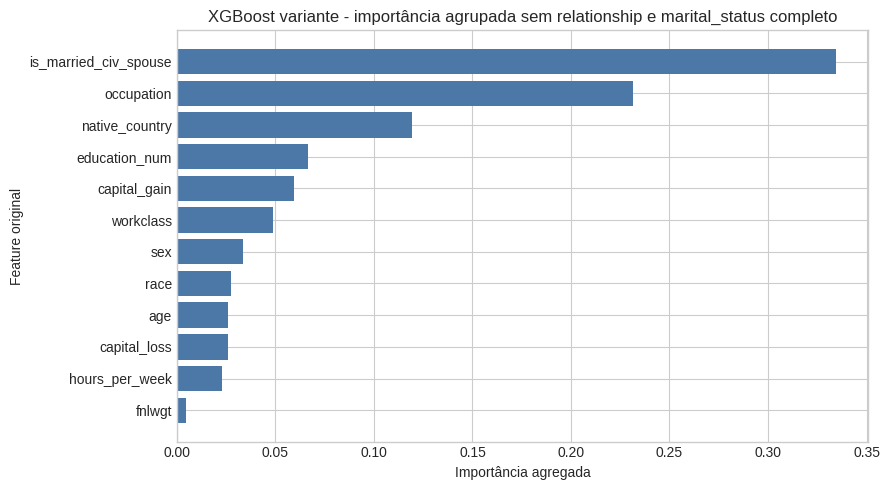

In [21]:

xgb_married = None
xgb_married_metrics = None
xgb_married_grouped_importance = None

if XGBOOST_AVAILABLE:
    scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    xgb_married = XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
    )
    xgb_married.fit(X_train_married, y_train)
    xgb_married_pred = xgb_married.predict(X_test_married)
    xgb_married_metrics = evaluate_predictions(
        y_test,
        xgb_married_pred,
        'XGBoost - is_married_civ_spouse sem relationship',
    )
    xgb_married_grouped_importance = aggregate_importances(xgb_married.feature_importances_, married_feature_groups)
    display(xgb_married_grouped_importance)
    plot_top_importances(
        xgb_married_grouped_importance,
        'XGBoost variante - importância agrupada sem relationship e marital_status completo',
    )
else:
    print('xgboost não está instalado. Variante XGBoost não executada.')


,model,accuracy,precision_>50K,recall_>50K,f1_>50K
0,RF original: marital_status completo + relatio...,0.840857,0.626947,0.805772,0.705200
1,RF variante: is_married_civ_spouse sem relatio...,0.841533,0.628921,0.802912,0.705345
2,XGB original: marital_status completo + relati...,0.831276,0.598849,0.865575,0.707921
3,XGB variante: is_married_civ_spouse sem relati...,0.831767,0.599856,0.864535,0.708276


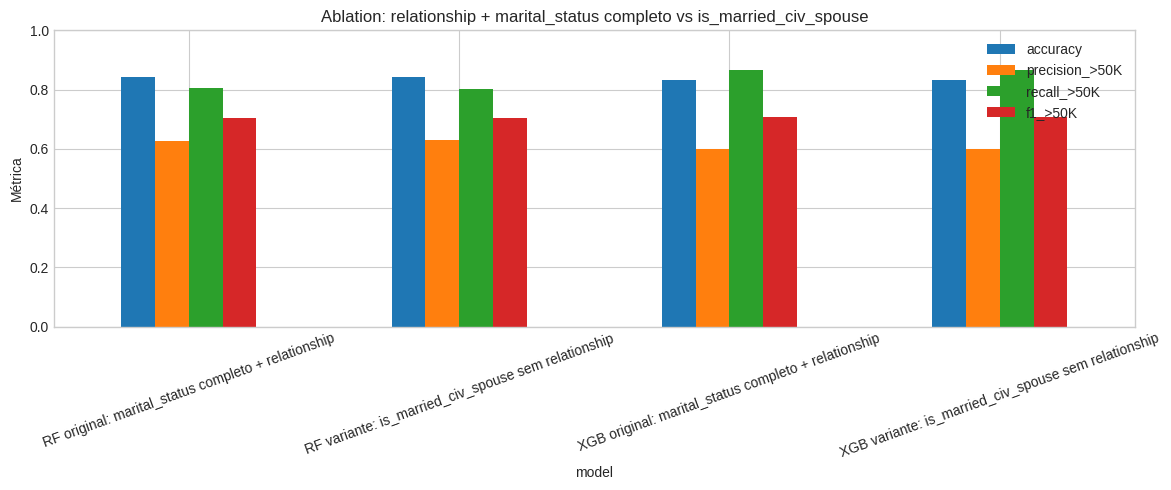

In [22]:

def metric_row(model_name, metrics):
    return {
        'model': model_name,
        'accuracy': metrics['accuracy'],
        'precision_>50K': metrics['precision'],
        'recall_>50K': metrics['recall'],
        'f1_>50K': metrics['f1'],
    }

ablation_rows = [
    metric_row('RF original: marital_status completo + relationship', rf_metrics),
    metric_row('RF variante: is_married_civ_spouse sem relationship', rf_married_metrics),
]

if xgb_metrics is not None:
    ablation_rows.append(metric_row('XGB original: marital_status completo + relationship', xgb_metrics))
if xgb_married_metrics is not None:
    ablation_rows.append(metric_row('XGB variante: is_married_civ_spouse sem relationship', xgb_married_metrics))

ablation_comparison = pd.DataFrame(ablation_rows)
display(ablation_comparison)

metric_cols = ['accuracy', 'precision_>50K', 'recall_>50K', 'f1_>50K']
plot_comparison = ablation_comparison.set_index('model')[metric_cols]
fig, ax = plt.subplots(figsize=(12, 5))
plot_comparison.plot(kind='bar', ax=ax)
ax.set_title('Ablation: relationship + marital_status completo vs is_married_civ_spouse')
ax.set_ylabel('Métrica')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


In [23]:

importance_compare = rf_grouped_importance.rename(columns={'importance': 'rf_original_impurity'}).merge(
    rf_married_grouped_importance.rename(columns={'importance': 'rf_variant_impurity'}),
    on='feature',
    how='outer',
).merge(
    rf_perm_grouped[['feature', 'mean_drop_f1']].rename(columns={'mean_drop_f1': 'rf_original_perm_drop_f1'}),
    on='feature',
    how='outer',
).merge(
    rf_married_perm_grouped[['feature', 'mean_drop_f1']].rename(columns={'mean_drop_f1': 'rf_variant_perm_drop_f1'}),
    on='feature',
    how='outer',
).fillna(0)

importance_compare['delta_perm_variant_minus_original'] = (
    importance_compare['rf_variant_perm_drop_f1'] - importance_compare['rf_original_perm_drop_f1']
)
importance_compare = importance_compare.sort_values('rf_variant_perm_drop_f1', ascending=False).reset_index(drop=True)

display(importance_compare)


,feature,rf_original_impurity,rf_variant_impurity,rf_original_perm_drop_f1,rf_variant_perm_drop_f1,delta_perm_variant_minus_original
0,is_married_civ_spouse,0.000000,0.234507,0.000000,0.146028,0.146028
1,capital_gain,0.091521,0.101874,0.048028,0.054198,0.006170
2,age,0.111533,0.151777,0.038125,0.051005,0.012880
3,education_num,0.109321,0.120706,0.039926,0.041851,0.001925
4,occupation,0.096667,0.111469,0.036198,0.037019,0.000821
5,hours_per_week,0.060170,0.071416,0.017776,0.020848,0.003072
6,capital_loss,0.024111,0.029100,0.007713,0.008502,0.000788
7,workclass,0.027988,0.031189,0.005444,0.005985,0.000541
8,sex,0.031634,0.059189,-0.001314,0.004484,0.005797
9,fnlwgt,0.055038,0.060720,0.002238,0.003538,0.001300



### Leitura esperada do experimento

Se a variante mantiver F1/accuracy parecidos, isso indica que `relationship` e o one-hot completo de `marital_status` eram parcialmente redundantes, e que a divisão `Married-civ-spouse` vs demais captura boa parte do sinal.

Se houver queda clara, então as outras categorias de `marital_status` e/ou `relationship` carregam informação adicional útil para prever `>50K`.



## 11. Ablation inversa: `is_husband`/`is_wife` sem `marital_status`

Agora testamos a hipótese oposta:

- Removemos `marital_status`.
- Removemos o one-hot completo de `relationship`.
- Criamos apenas dois indicadores binários: `is_husband` e `is_wife`.

Esse experimento verifica se os papéis familiares `Husband`/`Wife` capturam o mesmo sinal que `Married-civ-spouse` e o estado civil completo.


In [24]:

def build_encoded_dataset_relationship_binary(train_df, test_df, drop_original_cols=None):
    drop_original_cols = set(drop_original_cols or [])
    train_variant = train_df.copy()
    test_variant = test_df.copy()

    train_variant['is_husband'] = (train_variant['relationship'] == 'Husband').astype(np.float32)
    test_variant['is_husband'] = (test_variant['relationship'] == 'Husband').astype(np.float32)
    train_variant['is_wife'] = (train_variant['relationship'] == 'Wife').astype(np.float32)
    test_variant['is_wife'] = (test_variant['relationship'] == 'Wife').astype(np.float32)

    numeric_cols = list(NUMERIC_COLS) + ['is_husband', 'is_wife']
    categorical_cols = list(CATEGORICAL_COLS)

    drop_original_cols.update({'marital_status', 'relationship'})

    numeric_cols = [c for c in numeric_cols if c not in drop_original_cols]
    categorical_cols = [c for c in categorical_cols if c not in drop_original_cols]

    selected_features = numeric_cols + categorical_cols
    X_train_variant_df = train_variant[selected_features].copy()
    X_test_variant_df = test_variant[selected_features].copy()

    combined = pd.concat([X_train_variant_df, X_test_variant_df], axis=0, ignore_index=True)
    combined_encoded = pd.get_dummies(combined, columns=categorical_cols, dtype=np.float32)

    X_train_variant = combined_encoded.iloc[:len(X_train_variant_df)].to_numpy(dtype=np.float32)
    X_test_variant = combined_encoded.iloc[len(X_train_variant_df):].to_numpy(dtype=np.float32)
    variant_feature_names = combined_encoded.columns.to_list()

    variant_feature_groups = {}
    for original in selected_features:
        if original in numeric_cols:
            variant_feature_groups[original] = [variant_feature_names.index(original)]
        else:
            prefix = original + '_'
            variant_feature_groups[original] = [i for i, name in enumerate(variant_feature_names) if name.startswith(prefix)]

    return X_train_variant, X_test_variant, variant_feature_names, variant_feature_groups, selected_features

X_train_relbin, X_test_relbin, relbin_feature_names, relbin_feature_groups, relbin_selected_features = build_encoded_dataset_relationship_binary(
    train_df,
    test_df,
    drop_original_cols={'education'},
)

print('Features originais usadas na variante relationship binária:')
print(relbin_selected_features)
print('X_train variante:', X_train_relbin.shape)
print('X_test variante :', X_test_relbin.shape)
print('Features agrupadas:', list(relbin_feature_groups.keys()))


Features originais usadas na variante relationship binária:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'is_husband', 'is_wife', 'workclass', 'occupation', 'race', 'sex', 'native_country']
X_train variante: (32561, 81)
X_test variante : (16281, 81)
Features agrupadas: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'is_husband', 'is_wife', 'workclass', 'occupation', 'race', 'sex', 'native_country']


Random Forest - is_husband/is_wife sem marital_status


,accuracy,precision,recall,f1
0,0.842823,0.633479,0.794072,0.704742


              precision    recall  f1-score   support

       <=50K       0.93      0.86      0.89     12435
        >50K       0.63      0.79      0.70      3846

    accuracy                           0.84     16281
   macro avg       0.78      0.83      0.80     16281
weighted avg       0.86      0.84      0.85     16281



,pred <=50K,pred >50K
real <=50K,10668,1767
real >50K,792,3054


,feature,importance
0,is_husband,0.166529
1,age,0.158683
2,education_num,0.123628
3,occupation,0.111047
4,capital_gain,0.099061
5,hours_per_week,0.073418
6,fnlwgt,0.064705
7,is_wife,0.061160
8,sex,0.054790
9,workclass,0.030270


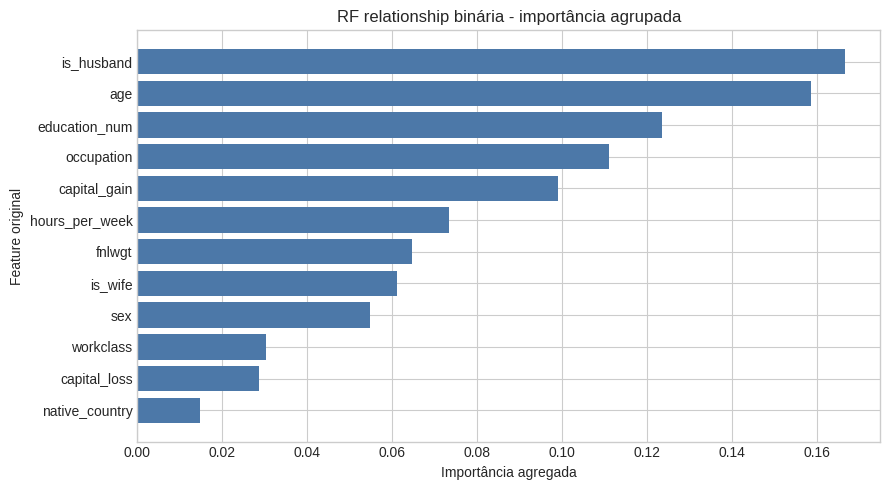

In [25]:

rf_relbin = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

rf_relbin.fit(X_train_relbin, y_train)
rf_relbin_pred = rf_relbin.predict(X_test_relbin)
rf_relbin_metrics = evaluate_predictions(
    y_test,
    rf_relbin_pred,
    'Random Forest - is_husband/is_wife sem marital_status',
)

rf_relbin_grouped_importance = aggregate_importances(rf_relbin.feature_importances_, relbin_feature_groups)
display(rf_relbin_grouped_importance)
plot_top_importances(
    rf_relbin_grouped_importance,
    'RF relationship binária - importância agrupada',
)


,feature,base_f1,mean_drop_f1,std_drop_f1
0,is_husband,0.704742,0.093446,0.003752
1,capital_gain,0.704742,0.054437,0.001575
2,age,0.704742,0.053108,0.003549
3,education_num,0.704742,0.041393,0.001851
4,occupation,0.704742,0.039532,0.002760
5,sex,0.704742,0.031048,0.002345
6,is_wife,0.704742,0.026620,0.000936
7,hours_per_week,0.704742,0.024373,0.002501
8,capital_loss,0.704742,0.009729,0.001144
9,workclass,0.704742,0.004951,0.000790


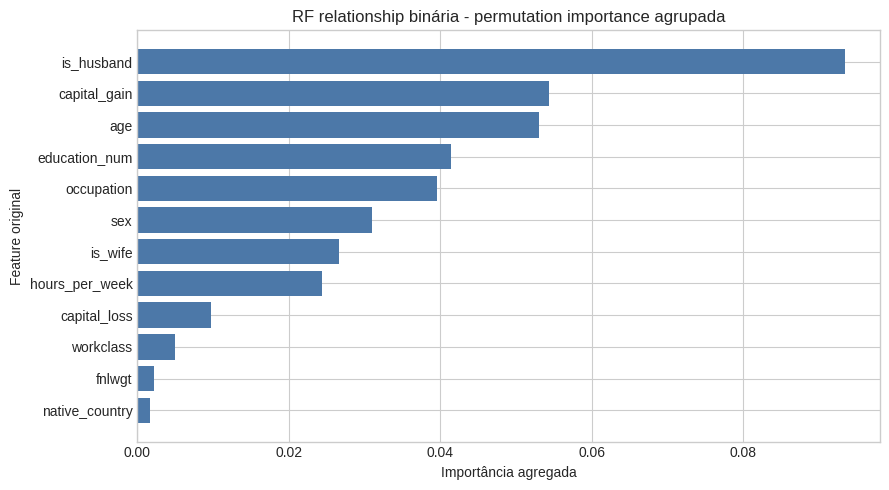

In [26]:

rf_relbin_perm_grouped = grouped_permutation_importance(
    rf_relbin,
    X_test_relbin,
    y_test,
    relbin_feature_groups,
    n_repeats=5,
    seed=SEED,
)

display(rf_relbin_perm_grouped)
plot_top_importances(
    rf_relbin_perm_grouped.rename(columns={'mean_drop_f1': 'importance'})[['feature', 'importance']],
    'RF relationship binária - permutation importance agrupada',
)


XGBoost - is_husband/is_wife sem marital_status


,accuracy,precision,recall,f1
0,0.832197,0.601494,0.858294,0.707307


              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88     12435
        >50K       0.60      0.86      0.71      3846

    accuracy                           0.83     16281
   macro avg       0.78      0.84      0.79     16281
weighted avg       0.87      0.83      0.84     16281



,pred <=50K,pred >50K
real <=50K,10248,2187
real >50K,545,3301


,feature,importance
0,is_husband,0.288141
1,occupation,0.208813
2,is_wife,0.102745
3,native_country,0.101242
4,education_num,0.059422
5,capital_gain,0.055097
6,workclass,0.045598
7,age,0.032123
8,race,0.028572
9,sex,0.026253


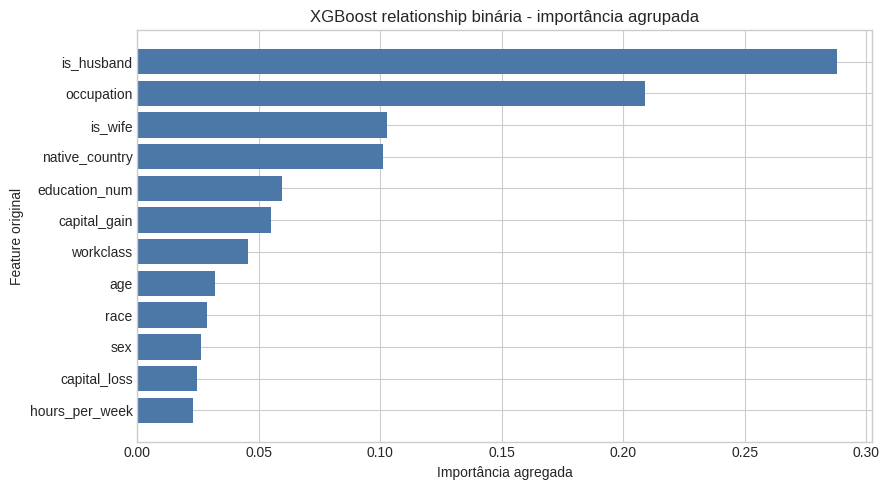

In [27]:

xgb_relbin = None
xgb_relbin_metrics = None
xgb_relbin_grouped_importance = None

if XGBOOST_AVAILABLE:
    scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    xgb_relbin = XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
    )
    xgb_relbin.fit(X_train_relbin, y_train)
    xgb_relbin_pred = xgb_relbin.predict(X_test_relbin)
    xgb_relbin_metrics = evaluate_predictions(
        y_test,
        xgb_relbin_pred,
        'XGBoost - is_husband/is_wife sem marital_status',
    )
    xgb_relbin_grouped_importance = aggregate_importances(xgb_relbin.feature_importances_, relbin_feature_groups)
    display(xgb_relbin_grouped_importance)
    plot_top_importances(
        xgb_relbin_grouped_importance,
        'XGBoost relationship binária - importância agrupada',
    )
else:
    print('xgboost não está instalado. Variante XGBoost relationship binária não executada.')


,model,accuracy,precision_>50K,recall_>50K,f1_>50K
0,RF original: marital_status completo + relatio...,0.840857,0.626947,0.805772,0.705200
1,RF variante A: is_married_civ_spouse sem relat...,0.841533,0.628921,0.802912,0.705345
2,RF variante B: is_husband/is_wife sem marital_...,0.842823,0.633479,0.794072,0.704742
3,XGB original: marital_status completo + relati...,0.831276,0.598849,0.865575,0.707921
4,XGB variante A: is_married_civ_spouse sem rela...,0.831767,0.599856,0.864535,0.708276
5,XGB variante B: is_husband/is_wife sem marital...,0.832197,0.601494,0.858294,0.707307


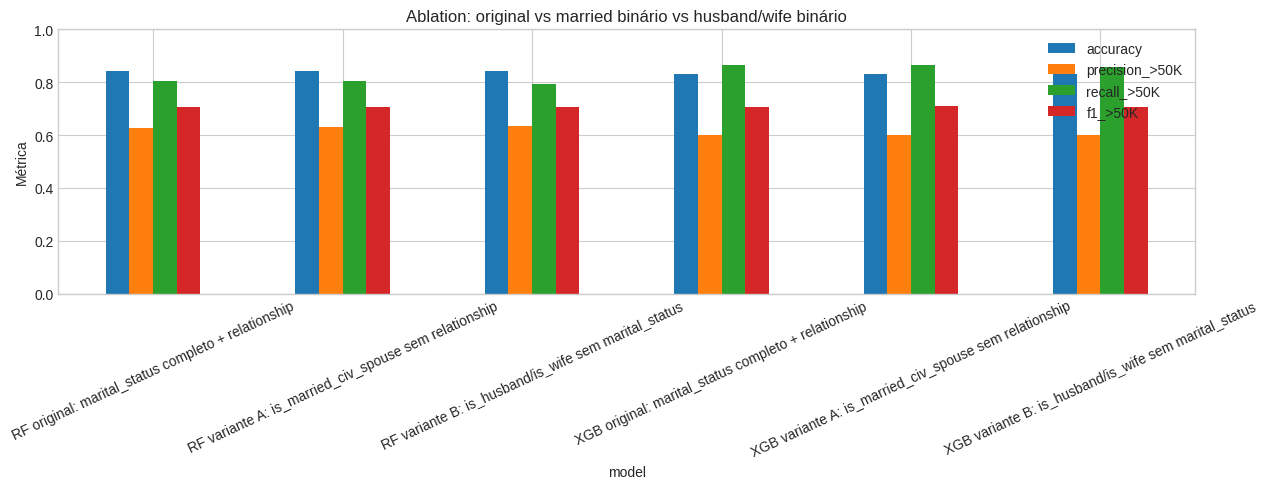

In [28]:

ablation_rows_2 = [
    metric_row('RF original: marital_status completo + relationship', rf_metrics),
    metric_row('RF variante A: is_married_civ_spouse sem relationship', rf_married_metrics),
    metric_row('RF variante B: is_husband/is_wife sem marital_status', rf_relbin_metrics),
]

if xgb_metrics is not None:
    ablation_rows_2.append(metric_row('XGB original: marital_status completo + relationship', xgb_metrics))
if xgb_married_metrics is not None:
    ablation_rows_2.append(metric_row('XGB variante A: is_married_civ_spouse sem relationship', xgb_married_metrics))
if xgb_relbin_metrics is not None:
    ablation_rows_2.append(metric_row('XGB variante B: is_husband/is_wife sem marital_status', xgb_relbin_metrics))

ablation_comparison_2 = pd.DataFrame(ablation_rows_2)
display(ablation_comparison_2)

plot_comparison_2 = ablation_comparison_2.set_index('model')[metric_cols]
fig, ax = plt.subplots(figsize=(13, 5))
plot_comparison_2.plot(kind='bar', ax=ax)
ax.set_title('Ablation: original vs married binário vs husband/wife binário')
ax.set_ylabel('Métrica')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


In [29]:

relbin_importance_compare = rf_grouped_importance.rename(columns={'importance': 'rf_original_impurity'}).merge(
    rf_married_grouped_importance.rename(columns={'importance': 'rf_married_variant_impurity'}),
    on='feature',
    how='outer',
).merge(
    rf_relbin_grouped_importance.rename(columns={'importance': 'rf_relbin_variant_impurity'}),
    on='feature',
    how='outer',
).merge(
    rf_perm_grouped[['feature', 'mean_drop_f1']].rename(columns={'mean_drop_f1': 'rf_original_perm_drop_f1'}),
    on='feature',
    how='outer',
).merge(
    rf_married_perm_grouped[['feature', 'mean_drop_f1']].rename(columns={'mean_drop_f1': 'rf_married_variant_perm_drop_f1'}),
    on='feature',
    how='outer',
).merge(
    rf_relbin_perm_grouped[['feature', 'mean_drop_f1']].rename(columns={'mean_drop_f1': 'rf_relbin_variant_perm_drop_f1'}),
    on='feature',
    how='outer',
).fillna(0)

relbin_importance_compare = relbin_importance_compare.sort_values(
    'rf_relbin_variant_perm_drop_f1', ascending=False
).reset_index(drop=True)

display(relbin_importance_compare)


,feature,rf_original_impurity,rf_married_variant_impurity,rf_relbin_variant_impurity,rf_original_perm_drop_f1,rf_married_variant_perm_drop_f1,rf_relbin_variant_perm_drop_f1
0,is_husband,0.000000,0.000000,0.166529,0.000000,0.000000,0.093446
1,capital_gain,0.091521,0.101874,0.099061,0.048028,0.054198,0.054437
2,age,0.111533,0.151777,0.158683,0.038125,0.051005,0.053108
3,education_num,0.109321,0.120706,0.123628,0.039926,0.041851,0.041393
4,occupation,0.096667,0.111469,0.111047,0.036198,0.037019,0.039532
5,sex,0.031634,0.059189,0.054790,-0.001314,0.004484,0.031048
6,is_wife,0.000000,0.000000,0.061160,0.000000,0.000000,0.026620
7,hours_per_week,0.060170,0.071416,0.073418,0.017776,0.020848,0.024373
8,capital_loss,0.024111,0.029100,0.028567,0.007713,0.008502,0.009729
9,workclass,0.027988,0.031189,0.030270,0.005444,0.005985,0.004951



### Leitura esperada da ablação inversa

Se `is_husband`/`is_wife` alcançar desempenho parecido com `is_married_civ_spouse`, então o sinal principal pode estar mais relacionado ao papel familiar do que ao estado civil em si.

Se perder desempenho, `Married-civ-spouse` é uma representação mais compacta e informativa do padrão familiar associado a `>50K`.



## 12. Ablation: removendo `sex`

Agora testamos se remover o atributo sensível `sex` muda o desempenho. Este experimento usa a variante compacta `is_married_civ_spouse` sem `relationship`, e remove também `sex`.

A pergunta é dupla:

- O desempenho cai quando `sex` é removido?
- Outros atributos continuam funcionando como proxies de gênero/estrutura familiar?


In [30]:

X_train_no_sex, X_test_no_sex, no_sex_feature_names, no_sex_feature_groups, no_sex_selected_features = build_encoded_dataset_variant(
    train_df,
    test_df,
    use_married_binary=True,
    drop_original_cols={'education', 'relationship', 'sex'},
)

print('Features originais usadas na variante sem sex:')
print(no_sex_selected_features)
print('X_train variante:', X_train_no_sex.shape)
print('X_test variante :', X_test_no_sex.shape)
print('Features agrupadas:', list(no_sex_feature_groups.keys()))


Features originais usadas na variante sem sex:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'is_married_civ_spouse', 'workclass', 'occupation', 'race', 'native_country']
X_train variante: (32561, 78)
X_test variante : (16281, 78)
Features agrupadas: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'is_married_civ_spouse', 'workclass', 'occupation', 'race', 'native_country']


Random Forest - is_married_civ_spouse sem relationship e sem sex


,accuracy,precision,recall,f1
0,0.842209,0.631082,0.799272,0.705289


              precision    recall  f1-score   support

       <=50K       0.93      0.86      0.89     12435
        >50K       0.63      0.80      0.71      3846

    accuracy                           0.84     16281
   macro avg       0.78      0.83      0.80     16281
weighted avg       0.86      0.84      0.85     16281



,pred <=50K,pred >50K
real <=50K,10638,1797
real >50K,772,3074


,feature,importance
0,is_married_civ_spouse,0.253184
1,age,0.171412
2,occupation,0.121824
3,education_num,0.119986
4,capital_gain,0.096341
5,hours_per_week,0.080665
6,fnlwgt,0.064569
7,workclass,0.032438
8,capital_loss,0.029034
9,native_country,0.015491


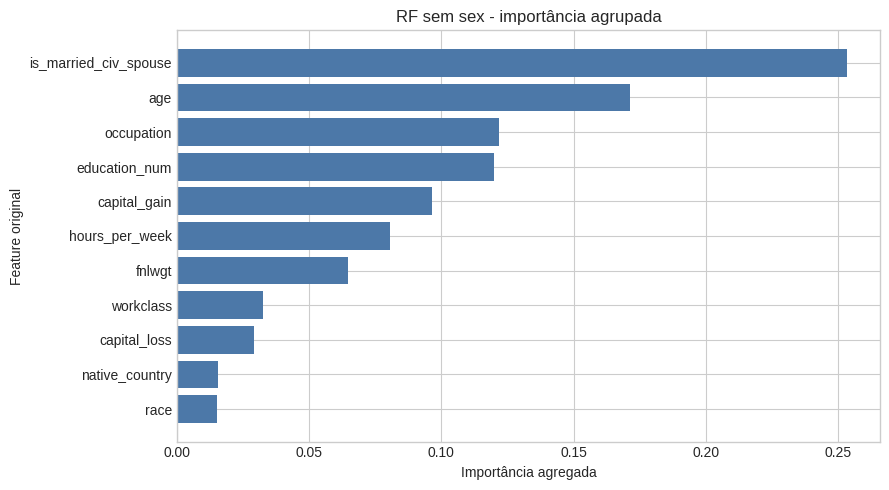

In [31]:

rf_no_sex = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

rf_no_sex.fit(X_train_no_sex, y_train)
rf_no_sex_pred = rf_no_sex.predict(X_test_no_sex)
rf_no_sex_metrics = evaluate_predictions(
    y_test,
    rf_no_sex_pred,
    'Random Forest - is_married_civ_spouse sem relationship e sem sex',
)

rf_no_sex_grouped_importance = aggregate_importances(rf_no_sex.feature_importances_, no_sex_feature_groups)
display(rf_no_sex_grouped_importance)
plot_top_importances(
    rf_no_sex_grouped_importance,
    'RF sem sex - importância agrupada',
)


,feature,base_f1,mean_drop_f1,std_drop_f1
0,is_married_civ_spouse,0.705289,0.156755,0.004837
1,capital_gain,0.705289,0.051529,0.001481
2,age,0.705289,0.051304,0.003740
3,occupation,0.705289,0.041020,0.002258
4,education_num,0.705289,0.040834,0.003326
5,hours_per_week,0.705289,0.017718,0.002729
6,capital_loss,0.705289,0.009322,0.001039
7,workclass,0.705289,0.006465,0.002009
8,fnlwgt,0.705289,0.002149,0.001279
9,race,0.705289,0.001343,0.000779


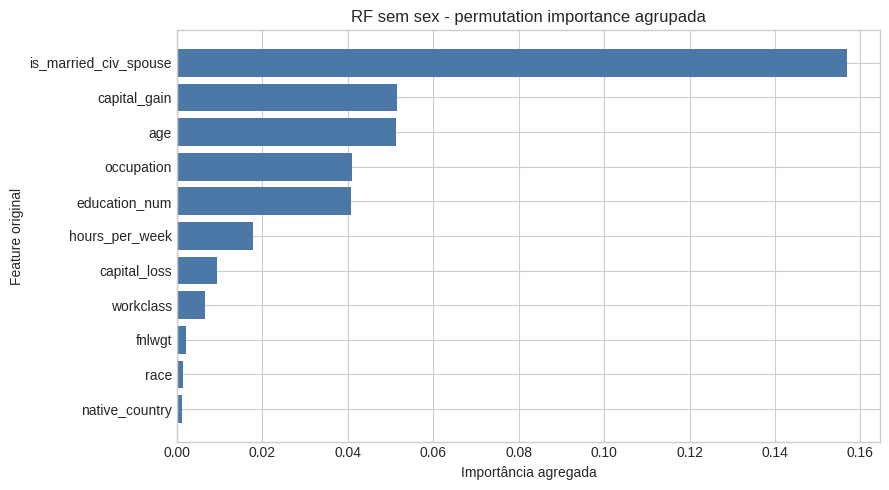

In [32]:

rf_no_sex_perm_grouped = grouped_permutation_importance(
    rf_no_sex,
    X_test_no_sex,
    y_test,
    no_sex_feature_groups,
    n_repeats=5,
    seed=SEED,
)

display(rf_no_sex_perm_grouped)
plot_top_importances(
    rf_no_sex_perm_grouped.rename(columns={'mean_drop_f1': 'importance'})[['feature', 'importance']],
    'RF sem sex - permutation importance agrupada',
)


XGBoost - is_married_civ_spouse sem relationship e sem sex


,accuracy,precision,recall,f1
0,0.830784,0.598059,0.865055,0.707195


              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88     12435
        >50K       0.60      0.87      0.71      3846

    accuracy                           0.83     16281
   macro avg       0.77      0.84      0.79     16281
weighted avg       0.87      0.83      0.84     16281



,pred <=50K,pred >50K
real <=50K,10199,2236
real >50K,519,3327


,feature,importance
0,is_married_civ_spouse,0.350220
1,occupation,0.239278
2,native_country,0.117656
3,education_num,0.067542
4,capital_gain,0.057782
5,workclass,0.053810
6,race,0.030799
7,age,0.028129
8,capital_loss,0.025815
9,hours_per_week,0.024167


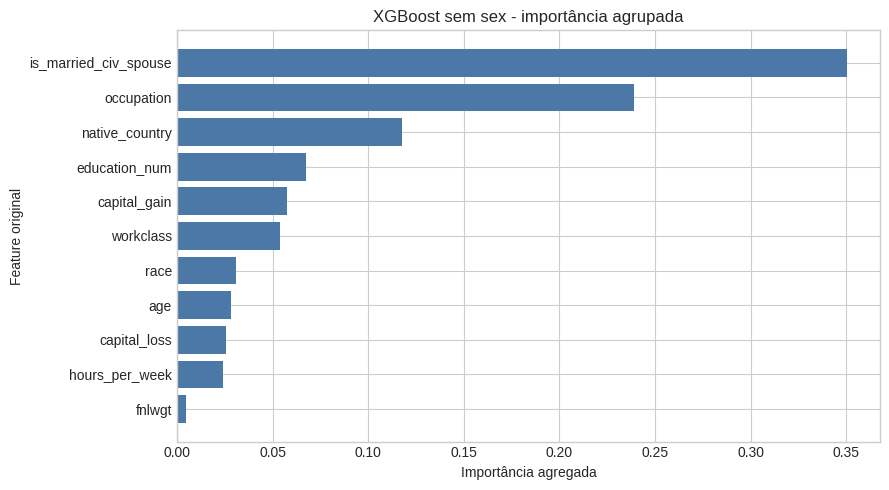

In [33]:

xgb_no_sex = None
xgb_no_sex_metrics = None
xgb_no_sex_grouped_importance = None

if XGBOOST_AVAILABLE:
    scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    xgb_no_sex = XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
    )
    xgb_no_sex.fit(X_train_no_sex, y_train)
    xgb_no_sex_pred = xgb_no_sex.predict(X_test_no_sex)
    xgb_no_sex_metrics = evaluate_predictions(
        y_test,
        xgb_no_sex_pred,
        'XGBoost - is_married_civ_spouse sem relationship e sem sex',
    )
    xgb_no_sex_grouped_importance = aggregate_importances(xgb_no_sex.feature_importances_, no_sex_feature_groups)
    display(xgb_no_sex_grouped_importance)
    plot_top_importances(
        xgb_no_sex_grouped_importance,
        'XGBoost sem sex - importância agrupada',
    )
else:
    print('xgboost não está instalado. Variante sem sex no XGBoost não executada.')


,model,accuracy,precision_>50K,recall_>50K,f1_>50K
0,RF original,0.840857,0.626947,0.805772,0.705200
1,RF married sem relationship,0.841533,0.628921,0.802912,0.705345
2,RF married sem relationship sem sex,0.842209,0.631082,0.799272,0.705289
3,XGB original,0.831276,0.598849,0.865575,0.707921
4,XGB married sem relationship,0.831767,0.599856,0.864535,0.708276
5,XGB married sem relationship sem sex,0.830784,0.598059,0.865055,0.707195


Taxa de predição >50K por sex - RF original


,count,P(pred >50K) by sex
group,,
Male,10860,0.398250
Female,5421,0.114001


Taxa de predição >50K por sex - RF sem sex


,count,P(pred >50K) by sex
group,,
Male,10860,0.388766
Female,5421,0.119720


Taxa de predição >50K por sex - XGB original


,count,P(pred >50K) by sex
group,,
Male,10860,0.442265
Female,5421,0.139458


Taxa de predição >50K por sex - XGB sem sex


,count,P(pred >50K) by sex
group,,
Male,10860,0.441344
Female,5421,0.142040


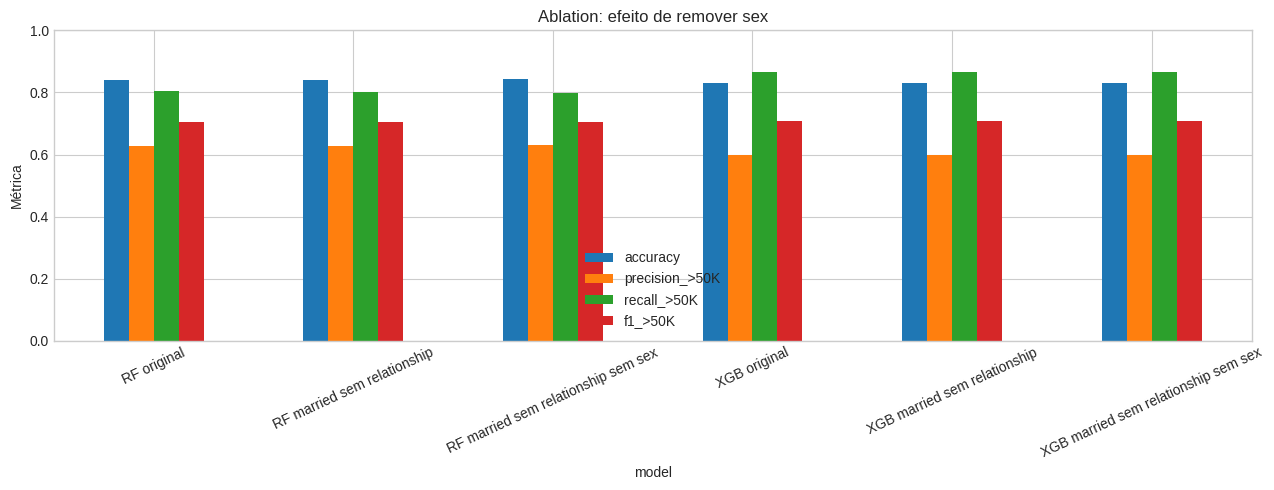

In [34]:

def selection_rate_by_group(y_pred, sensitive_values, group_name):
    df = pd.DataFrame({'group': sensitive_values, 'pred_high_income': y_pred})
    out = df.groupby('group')['pred_high_income'].agg(['count', 'mean']).sort_values('mean', ascending=False)
    out = out.rename(columns={'mean': f'P(pred >50K) by {group_name}'})
    return out

no_sex_rows = [
    metric_row('RF original', rf_metrics),
    metric_row('RF married sem relationship', rf_married_metrics),
    metric_row('RF married sem relationship sem sex', rf_no_sex_metrics),
]

if xgb_metrics is not None:
    no_sex_rows.append(metric_row('XGB original', xgb_metrics))
if xgb_married_metrics is not None:
    no_sex_rows.append(metric_row('XGB married sem relationship', xgb_married_metrics))
if xgb_no_sex_metrics is not None:
    no_sex_rows.append(metric_row('XGB married sem relationship sem sex', xgb_no_sex_metrics))

no_sex_comparison = pd.DataFrame(no_sex_rows)
display(no_sex_comparison)

print('Taxa de predição >50K por sex - RF original')
display(selection_rate_by_group(rf_pred, test_df['sex'], 'sex'))
print('Taxa de predição >50K por sex - RF sem sex')
display(selection_rate_by_group(rf_no_sex_pred, test_df['sex'], 'sex'))

if xgb_no_sex is not None:
    print('Taxa de predição >50K por sex - XGB original')
    display(selection_rate_by_group(xgb_pred, test_df['sex'], 'sex'))
    print('Taxa de predição >50K por sex - XGB sem sex')
    display(selection_rate_by_group(xgb_no_sex_pred, test_df['sex'], 'sex'))

plot_no_sex = no_sex_comparison.set_index('model')[metric_cols]
fig, ax = plt.subplots(figsize=(13, 5))
plot_no_sex.plot(kind='bar', ax=ax)
ax.set_title('Ablation: efeito de remover sex')
ax.set_ylabel('Métrica')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()



### Leitura esperada ao remover `sex`

Se o desempenho quase não mudar, isso sugere que `sex` não é essencial para a performance preditiva bruta. Porém, se as taxas de seleção por `sex` continuarem diferentes, isso mostra que o modelo ainda usa proxies como `is_married_civ_spouse`, ocupação, horas trabalhadas e capital.

Esse é exatamente o ponto conhecido como *fairness through unawareness*: remover o atributo sensível não garante remover o viés.



## 13. Ablation: sem `sex`, mantendo `relationship` e removendo `marital_status`

Nesta variante removemos:

- `sex`
- `marital_status`

E mantemos `relationship` completo em one-hot. A ideia é testar se `relationship` sozinho preserva o sinal familiar sem usar explicitamente o estado civil nem o sexo.


In [35]:

X_train_rel_no_sex, X_test_rel_no_sex, rel_no_sex_feature_names, rel_no_sex_feature_groups, rel_no_sex_selected_features = build_encoded_dataset_variant(
    train_df,
    test_df,
    use_married_binary=False,
    drop_original_cols={'education', 'marital_status', 'sex'},
)

print('Features originais usadas na variante relationship sem sex/marital_status:')
print(rel_no_sex_selected_features)
print('X_train variante:', X_train_rel_no_sex.shape)
print('X_test variante :', X_test_rel_no_sex.shape)
print('Features agrupadas:', list(rel_no_sex_feature_groups.keys()))


Features originais usadas na variante relationship sem sex/marital_status:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass', 'occupation', 'relationship', 'race', 'native_country']
X_train variante: (32561, 83)
X_test variante : (16281, 83)
Features agrupadas: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass', 'occupation', 'relationship', 'race', 'native_country']


Random Forest - relationship sem marital_status e sem sex


,accuracy,precision,recall,f1
0,0.841287,0.629516,0.797452,0.703602


              precision    recall  f1-score   support

       <=50K       0.93      0.85      0.89     12435
        >50K       0.63      0.80      0.70      3846

    accuracy                           0.84     16281
   macro avg       0.78      0.83      0.80     16281
weighted avg       0.86      0.84      0.85     16281



,pred <=50K,pred >50K
real <=50K,10630,1805
real >50K,779,3067


,feature,importance
0,relationship,0.315646
1,age,0.141375
2,education_num,0.124764
3,occupation,0.105790
4,capital_gain,0.096744
5,hours_per_week,0.069038
6,fnlwgt,0.061736
7,workclass,0.030844
8,capital_loss,0.026495
9,native_country,0.014465


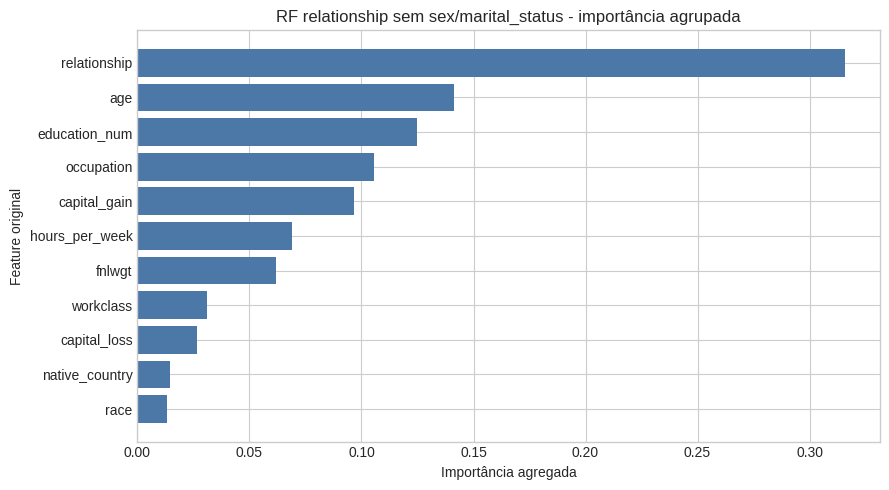

In [36]:

rf_rel_no_sex = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

rf_rel_no_sex.fit(X_train_rel_no_sex, y_train)
rf_rel_no_sex_pred = rf_rel_no_sex.predict(X_test_rel_no_sex)
rf_rel_no_sex_metrics = evaluate_predictions(
    y_test,
    rf_rel_no_sex_pred,
    'Random Forest - relationship sem marital_status e sem sex',
)

rf_rel_no_sex_grouped_importance = aggregate_importances(rf_rel_no_sex.feature_importances_, rel_no_sex_feature_groups)
display(rf_rel_no_sex_grouped_importance)
plot_top_importances(
    rf_rel_no_sex_grouped_importance,
    'RF relationship sem sex/marital_status - importância agrupada',
)


,feature,base_f1,mean_drop_f1,std_drop_f1
0,relationship,0.703602,0.180347,0.002775
1,capital_gain,0.703602,0.053188,0.000924
2,age,0.703602,0.044796,0.002422
3,education_num,0.703602,0.042860,0.001417
4,occupation,0.703602,0.036197,0.006122
5,hours_per_week,0.703602,0.021891,0.002448
6,capital_loss,0.703602,0.008818,0.001459
7,workclass,0.703602,0.005830,0.002140
8,fnlwgt,0.703602,0.001432,0.000750
9,native_country,0.703602,0.001195,0.000918


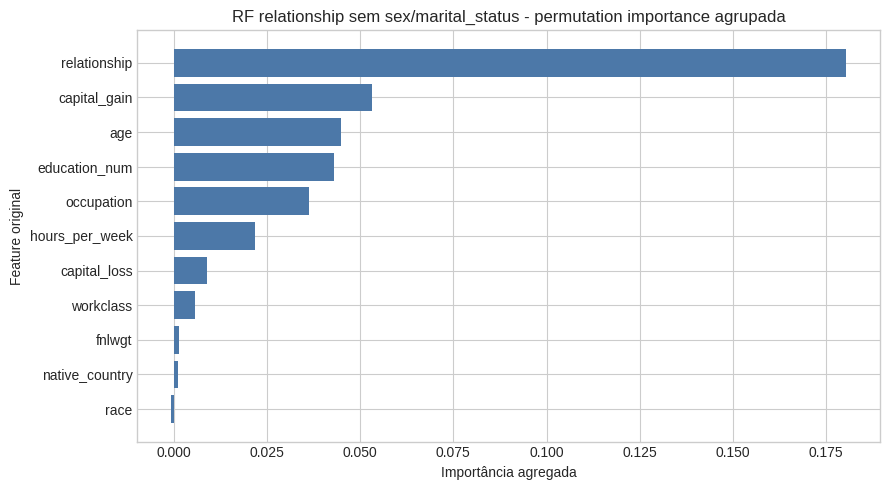

In [37]:

rf_rel_no_sex_perm_grouped = grouped_permutation_importance(
    rf_rel_no_sex,
    X_test_rel_no_sex,
    y_test,
    rel_no_sex_feature_groups,
    n_repeats=5,
    seed=SEED,
)

display(rf_rel_no_sex_perm_grouped)
plot_top_importances(
    rf_rel_no_sex_perm_grouped.rename(columns={'mean_drop_f1': 'importance'})[['feature', 'importance']],
    'RF relationship sem sex/marital_status - permutation importance agrupada',
)


XGBoost - relationship sem marital_status e sem sex


,accuracy,precision,recall,f1
0,0.83146,0.599891,0.860374,0.7069


              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88     12435
        >50K       0.60      0.86      0.71      3846

    accuracy                           0.83     16281
   macro avg       0.78      0.84      0.79     16281
weighted avg       0.87      0.83      0.84     16281



,pred <=50K,pred >50K
real <=50K,10228,2207
real >50K,537,3309


,feature,importance
0,relationship,0.462955
1,occupation,0.191116
2,native_country,0.090932
3,education_num,0.056217
4,capital_gain,0.048536
5,workclass,0.043502
6,age,0.034363
7,race,0.027081
8,capital_loss,0.021128
9,hours_per_week,0.020411


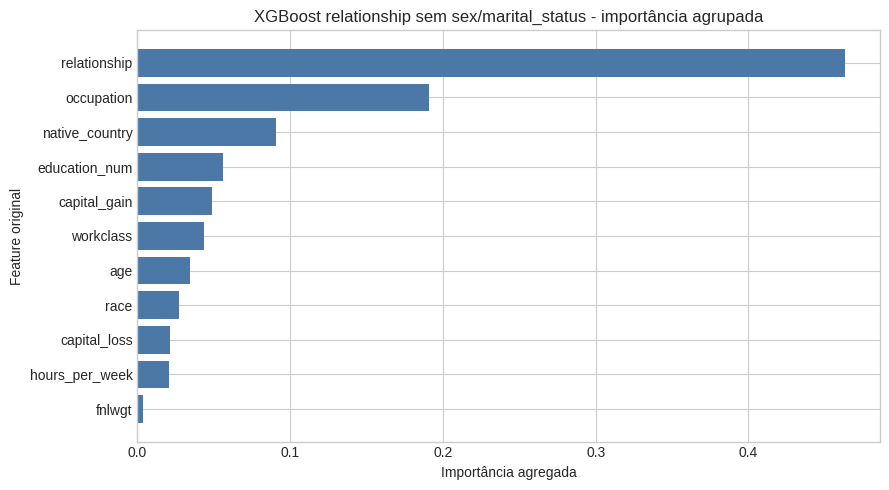

In [38]:

xgb_rel_no_sex = None
xgb_rel_no_sex_metrics = None
xgb_rel_no_sex_grouped_importance = None

if XGBOOST_AVAILABLE:
    scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    xgb_rel_no_sex = XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
    )
    xgb_rel_no_sex.fit(X_train_rel_no_sex, y_train)
    xgb_rel_no_sex_pred = xgb_rel_no_sex.predict(X_test_rel_no_sex)
    xgb_rel_no_sex_metrics = evaluate_predictions(
        y_test,
        xgb_rel_no_sex_pred,
        'XGBoost - relationship sem marital_status e sem sex',
    )
    xgb_rel_no_sex_grouped_importance = aggregate_importances(xgb_rel_no_sex.feature_importances_, rel_no_sex_feature_groups)
    display(xgb_rel_no_sex_grouped_importance)
    plot_top_importances(
        xgb_rel_no_sex_grouped_importance,
        'XGBoost relationship sem sex/marital_status - importância agrupada',
    )
else:
    print('xgboost não está instalado. Variante relationship sem sex/marital_status no XGBoost não executada.')


,model,accuracy,precision_>50K,recall_>50K,f1_>50K
0,RF original,0.840857,0.626947,0.805772,0.705200
1,RF married sem relationship sem sex,0.842209,0.631082,0.799272,0.705289
2,RF relationship sem marital_status sem sex,0.841287,0.629516,0.797452,0.703602
3,XGB original,0.831276,0.598849,0.865575,0.707921
4,XGB married sem relationship sem sex,0.830784,0.598059,0.865055,0.707195
5,XGB relationship sem marital_status sem sex,0.831460,0.599891,0.860374,0.706900


Taxa de predição >50K por sex - RF relationship sem sex/marital_status


,count,P(pred >50K) by sex
group,,
Male,10860,0.387109
Female,5421,0.123224


Taxa de predição >50K por sex - XGB relationship sem sex/marital_status


,count,P(pred >50K) by sex
group,,
Male,10860,0.433702
Female,5421,0.148681


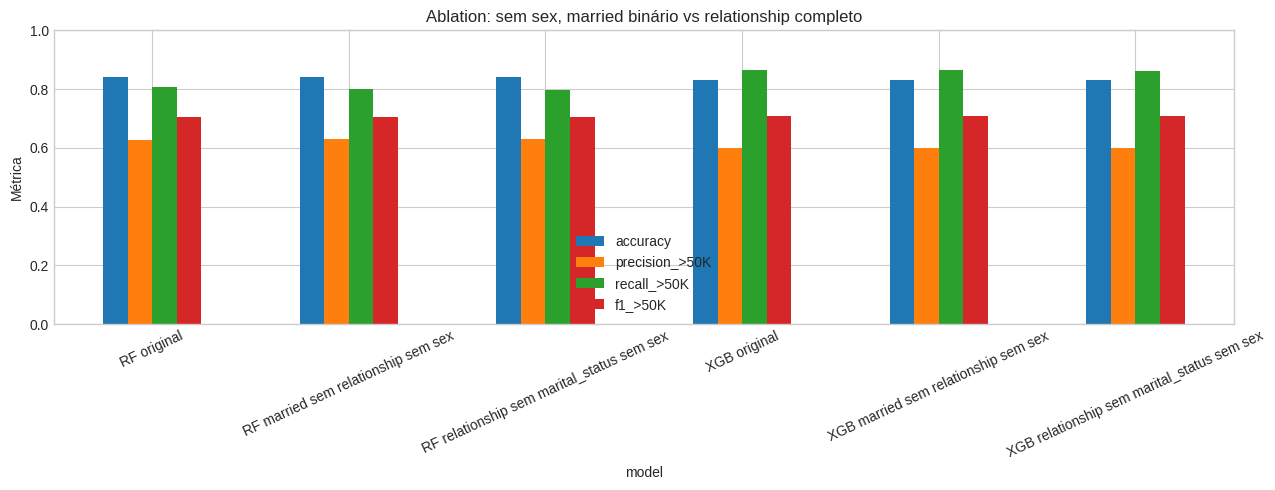

In [39]:

rel_no_sex_rows = [
    metric_row('RF original', rf_metrics),
    metric_row('RF married sem relationship sem sex', rf_no_sex_metrics),
    metric_row('RF relationship sem marital_status sem sex', rf_rel_no_sex_metrics),
]

if xgb_metrics is not None:
    rel_no_sex_rows.append(metric_row('XGB original', xgb_metrics))
if xgb_no_sex_metrics is not None:
    rel_no_sex_rows.append(metric_row('XGB married sem relationship sem sex', xgb_no_sex_metrics))
if xgb_rel_no_sex_metrics is not None:
    rel_no_sex_rows.append(metric_row('XGB relationship sem marital_status sem sex', xgb_rel_no_sex_metrics))

rel_no_sex_comparison = pd.DataFrame(rel_no_sex_rows)
display(rel_no_sex_comparison)

print('Taxa de predição >50K por sex - RF relationship sem sex/marital_status')
display(selection_rate_by_group(rf_rel_no_sex_pred, test_df['sex'], 'sex'))

if xgb_rel_no_sex is not None:
    print('Taxa de predição >50K por sex - XGB relationship sem sex/marital_status')
    display(selection_rate_by_group(xgb_rel_no_sex_pred, test_df['sex'], 'sex'))

plot_rel_no_sex = rel_no_sex_comparison.set_index('model')[metric_cols]
fig, ax = plt.subplots(figsize=(13, 5))
plot_rel_no_sex.plot(kind='bar', ax=ax)
ax.set_title('Ablation: sem sex, married binário vs relationship completo')
ax.set_ylabel('Métrica')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


In [40]:

rel_no_sex_importance_compare = rf_no_sex_grouped_importance.rename(columns={'importance': 'rf_married_no_sex_impurity'}).merge(
    rf_rel_no_sex_grouped_importance.rename(columns={'importance': 'rf_relationship_no_sex_impurity'}),
    on='feature',
    how='outer',
).merge(
    rf_no_sex_perm_grouped[['feature', 'mean_drop_f1']].rename(columns={'mean_drop_f1': 'rf_married_no_sex_perm_drop_f1'}),
    on='feature',
    how='outer',
).merge(
    rf_rel_no_sex_perm_grouped[['feature', 'mean_drop_f1']].rename(columns={'mean_drop_f1': 'rf_relationship_no_sex_perm_drop_f1'}),
    on='feature',
    how='outer',
).fillna(0)

rel_no_sex_importance_compare = rel_no_sex_importance_compare.sort_values(
    'rf_relationship_no_sex_perm_drop_f1', ascending=False
).reset_index(drop=True)

display(rel_no_sex_importance_compare)


,feature,rf_married_no_sex_impurity,rf_relationship_no_sex_impurity,rf_married_no_sex_perm_drop_f1,rf_relationship_no_sex_perm_drop_f1
0,relationship,0.000000,0.315646,0.000000,0.180347
1,capital_gain,0.096341,0.096744,0.051529,0.053188
2,age,0.171412,0.141375,0.051304,0.044796
3,education_num,0.119986,0.124764,0.040834,0.042860
4,occupation,0.121824,0.105790,0.041020,0.036197
5,hours_per_week,0.080665,0.069038,0.017718,0.021891
6,capital_loss,0.029034,0.026495,0.009322,0.008818
7,workclass,0.032438,0.030844,0.006465,0.005830
8,fnlwgt,0.064569,0.061736,0.002149,0.001432
9,native_country,0.015491,0.014465,0.001163,0.001195



### Leitura esperada

Se `relationship` completo sem `sex` e sem `marital_status` mantiver desempenho semelhante, então ele carrega boa parte do sinal familiar por conta própria. Se as taxas de seleção por `sex` continuarem distantes, isso indica que `relationship` age como proxy forte de gênero/estrutura familiar.



## 14. Ablation exata: sem `sex`, sem `marital_status`, com apenas `is_husband` e `is_wife`

Esta é a variante mais específica:

- Remove `sex`.
- Remove `marital_status`.
- Remove `relationship` completo.
- Mantém apenas dois indicadores derivados de `relationship`: `is_husband` e `is_wife`.

Ela testa se os papéis `Husband` e `Wife` sozinhos capturam o sinal familiar sem usar explicitamente sexo nem estado civil.


In [41]:

X_train_relbin_no_sex, X_test_relbin_no_sex, relbin_no_sex_feature_names, relbin_no_sex_feature_groups, relbin_no_sex_selected_features = build_encoded_dataset_relationship_binary(
    train_df,
    test_df,
    drop_original_cols={'education', 'sex'},
)

print('Features originais usadas na variante is_husband/is_wife sem sex/marital_status:')
print(relbin_no_sex_selected_features)
print('X_train variante:', X_train_relbin_no_sex.shape)
print('X_test variante :', X_test_relbin_no_sex.shape)
print('Features agrupadas:', list(relbin_no_sex_feature_groups.keys()))


Features originais usadas na variante is_husband/is_wife sem sex/marital_status:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'is_husband', 'is_wife', 'workclass', 'occupation', 'race', 'native_country']
X_train variante: (32561, 79)
X_test variante : (16281, 79)
Features agrupadas: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'is_husband', 'is_wife', 'workclass', 'occupation', 'race', 'native_country']


Random Forest - is_husband/is_wife sem marital_status e sem sex


,accuracy,precision,recall,f1
0,0.840243,0.628802,0.790172,0.700311


              precision    recall  f1-score   support

       <=50K       0.93      0.86      0.89     12435
        >50K       0.63      0.79      0.70      3846

    accuracy                           0.84     16281
   macro avg       0.78      0.82      0.80     16281
weighted avg       0.86      0.84      0.85     16281



,pred <=50K,pred >50K
real <=50K,10641,1794
real >50K,807,3039


,feature,importance
0,is_husband,0.205450
1,age,0.157114
2,education_num,0.125857
3,occupation,0.121058
4,capital_gain,0.104894
5,hours_per_week,0.078055
6,fnlwgt,0.064411
7,is_wife,0.049428
8,workclass,0.033124
9,capital_loss,0.030478


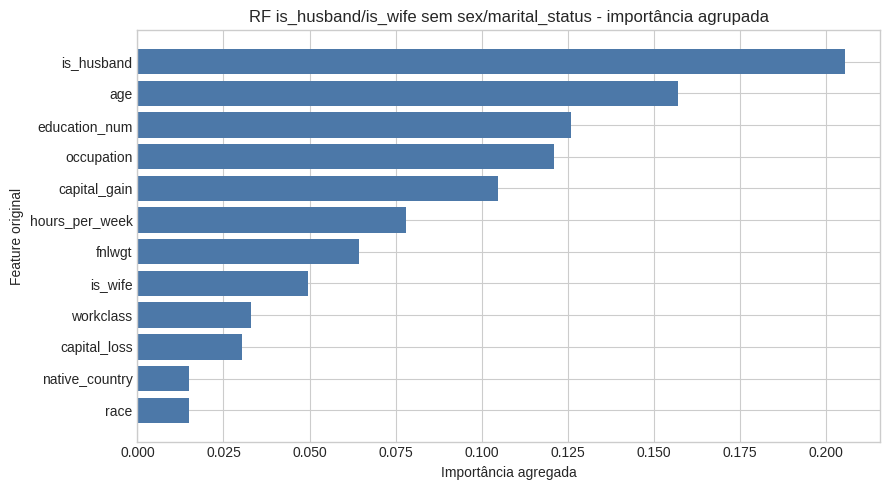

In [42]:

rf_relbin_no_sex = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

rf_relbin_no_sex.fit(X_train_relbin_no_sex, y_train)
rf_relbin_no_sex_pred = rf_relbin_no_sex.predict(X_test_relbin_no_sex)
rf_relbin_no_sex_metrics = evaluate_predictions(
    y_test,
    rf_relbin_no_sex_pred,
    'Random Forest - is_husband/is_wife sem marital_status e sem sex',
)

rf_relbin_no_sex_grouped_importance = aggregate_importances(rf_relbin_no_sex.feature_importances_, relbin_no_sex_feature_groups)
display(rf_relbin_no_sex_grouped_importance)
plot_top_importances(
    rf_relbin_no_sex_grouped_importance,
    'RF is_husband/is_wife sem sex/marital_status - importância agrupada',
)


,feature,base_f1,mean_drop_f1,std_drop_f1
0,is_husband,0.700311,0.127214,0.004182
1,capital_gain,0.700311,0.055118,0.001259
2,age,0.700311,0.047226,0.002343
3,education_num,0.700311,0.037001,0.003743
4,occupation,0.700311,0.035480,0.001961
5,is_wife,0.700311,0.026288,0.001376
6,hours_per_week,0.700311,0.023998,0.002479
7,capital_loss,0.700311,0.009285,0.000784
8,workclass,0.700311,0.004757,0.001114
9,native_country,0.700311,0.000702,0.000757


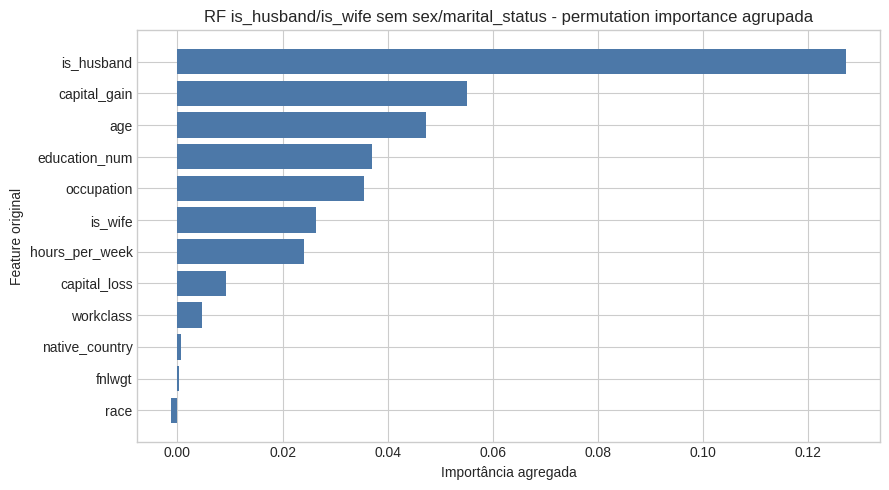

In [43]:

rf_relbin_no_sex_perm_grouped = grouped_permutation_importance(
    rf_relbin_no_sex,
    X_test_relbin_no_sex,
    y_test,
    relbin_no_sex_feature_groups,
    n_repeats=5,
    seed=SEED,
)

display(rf_relbin_no_sex_perm_grouped)
plot_top_importances(
    rf_relbin_no_sex_perm_grouped.rename(columns={'mean_drop_f1': 'importance'})[['feature', 'importance']],
    'RF is_husband/is_wife sem sex/marital_status - permutation importance agrupada',
)


XGBoost - is_husband/is_wife sem marital_status e sem sex


,accuracy,precision,recall,f1
0,0.83232,0.601455,0.860114,0.707896


              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88     12435
        >50K       0.60      0.86      0.71      3846

    accuracy                           0.83     16281
   macro avg       0.78      0.84      0.80     16281
weighted avg       0.87      0.83      0.84     16281



,pred <=50K,pred >50K
real <=50K,10243,2192
real >50K,538,3308


,feature,importance
0,is_husband,0.271519
1,occupation,0.233032
2,is_wife,0.102515
3,native_country,0.101772
4,education_num,0.061041
5,capital_gain,0.056061
6,workclass,0.052388
7,age,0.036713
8,race,0.032060
9,hours_per_week,0.024692


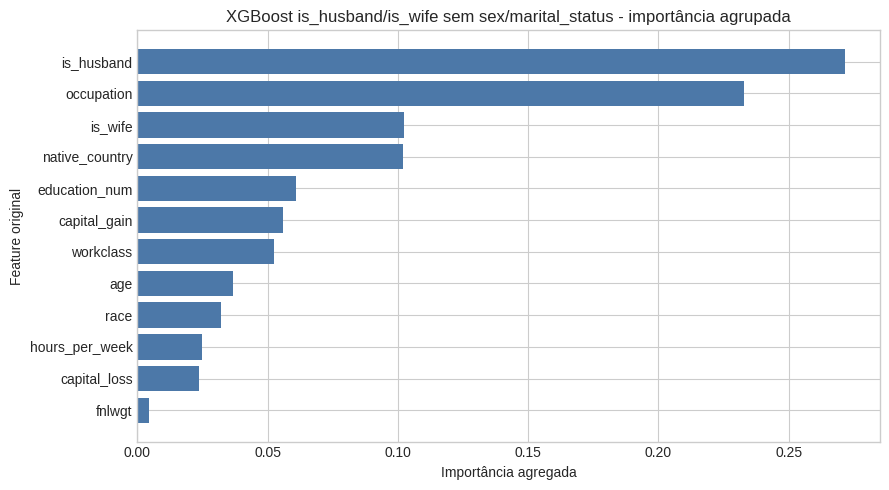

In [44]:

xgb_relbin_no_sex = None
xgb_relbin_no_sex_metrics = None
xgb_relbin_no_sex_grouped_importance = None

if XGBOOST_AVAILABLE:
    scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    xgb_relbin_no_sex = XGBClassifier(
        n_estimators=350,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
    )
    xgb_relbin_no_sex.fit(X_train_relbin_no_sex, y_train)
    xgb_relbin_no_sex_pred = xgb_relbin_no_sex.predict(X_test_relbin_no_sex)
    xgb_relbin_no_sex_metrics = evaluate_predictions(
        y_test,
        xgb_relbin_no_sex_pred,
        'XGBoost - is_husband/is_wife sem marital_status e sem sex',
    )
    xgb_relbin_no_sex_grouped_importance = aggregate_importances(xgb_relbin_no_sex.feature_importances_, relbin_no_sex_feature_groups)
    display(xgb_relbin_no_sex_grouped_importance)
    plot_top_importances(
        xgb_relbin_no_sex_grouped_importance,
        'XGBoost is_husband/is_wife sem sex/marital_status - importância agrupada',
    )
else:
    print('xgboost não está instalado. Variante is_husband/is_wife sem sex/marital_status no XGBoost não executada.')


,model,accuracy,precision_>50K,recall_>50K,f1_>50K
0,RF original,0.840857,0.626947,0.805772,0.705200
1,RF married sem relationship sem sex,0.842209,0.631082,0.799272,0.705289
2,RF relationship completo sem marital_status se...,0.841287,0.629516,0.797452,0.703602
3,RF is_husband/is_wife sem marital_status sem sex,0.840243,0.628802,0.790172,0.700311
4,XGB original,0.831276,0.598849,0.865575,0.707921
5,XGB married sem relationship sem sex,0.830784,0.598059,0.865055,0.707195
6,XGB relationship completo sem marital_status s...,0.831460,0.599891,0.860374,0.706900
7,XGB is_husband/is_wife sem marital_status sem sex,0.832320,0.601455,0.860114,0.707896


Taxa de predição >50K por sex - RF is_husband/is_wife sem sex/marital_status


,count,P(pred >50K) by sex
group,,
Male,10860,0.384438
Female,5421,0.121380


Taxa de predição >50K por sex - XGB is_husband/is_wife sem sex/marital_status


,count,P(pred >50K) by sex
group,,
Male,10860,0.432044
Female,5421,0.149050


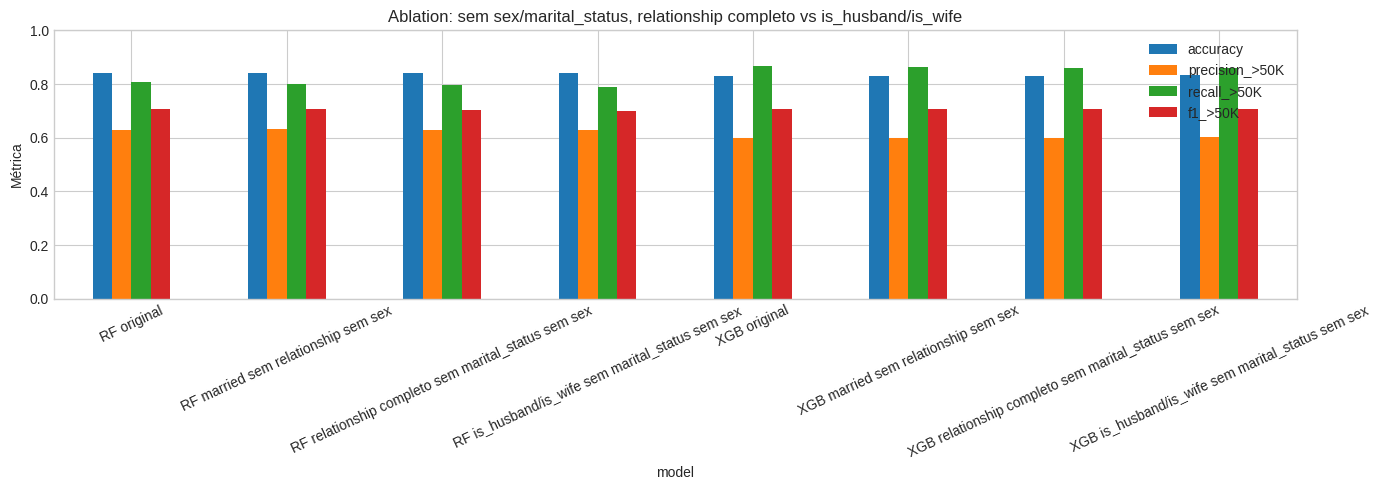

In [45]:

relbin_no_sex_rows = [
    metric_row('RF original', rf_metrics),
    metric_row('RF married sem relationship sem sex', rf_no_sex_metrics),
    metric_row('RF relationship completo sem marital_status sem sex', rf_rel_no_sex_metrics),
    metric_row('RF is_husband/is_wife sem marital_status sem sex', rf_relbin_no_sex_metrics),
]

if xgb_metrics is not None:
    relbin_no_sex_rows.append(metric_row('XGB original', xgb_metrics))
if xgb_no_sex_metrics is not None:
    relbin_no_sex_rows.append(metric_row('XGB married sem relationship sem sex', xgb_no_sex_metrics))
if xgb_rel_no_sex_metrics is not None:
    relbin_no_sex_rows.append(metric_row('XGB relationship completo sem marital_status sem sex', xgb_rel_no_sex_metrics))
if xgb_relbin_no_sex_metrics is not None:
    relbin_no_sex_rows.append(metric_row('XGB is_husband/is_wife sem marital_status sem sex', xgb_relbin_no_sex_metrics))

relbin_no_sex_comparison = pd.DataFrame(relbin_no_sex_rows)
display(relbin_no_sex_comparison)

print('Taxa de predição >50K por sex - RF is_husband/is_wife sem sex/marital_status')
display(selection_rate_by_group(rf_relbin_no_sex_pred, test_df['sex'], 'sex'))

if xgb_relbin_no_sex is not None:
    print('Taxa de predição >50K por sex - XGB is_husband/is_wife sem sex/marital_status')
    display(selection_rate_by_group(xgb_relbin_no_sex_pred, test_df['sex'], 'sex'))

plot_relbin_no_sex = relbin_no_sex_comparison.set_index('model')[metric_cols]
fig, ax = plt.subplots(figsize=(14, 5))
plot_relbin_no_sex.plot(kind='bar', ax=ax)
ax.set_title('Ablation: sem sex/marital_status, relationship completo vs is_husband/is_wife')
ax.set_ylabel('Métrica')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


In [46]:

relbin_no_sex_importance_compare = rf_rel_no_sex_grouped_importance.rename(columns={'importance': 'rf_relationship_full_no_sex_impurity'}).merge(
    rf_relbin_no_sex_grouped_importance.rename(columns={'importance': 'rf_husband_wife_no_sex_impurity'}),
    on='feature',
    how='outer',
).merge(
    rf_rel_no_sex_perm_grouped[['feature', 'mean_drop_f1']].rename(columns={'mean_drop_f1': 'rf_relationship_full_no_sex_perm_drop_f1'}),
    on='feature',
    how='outer',
).merge(
    rf_relbin_no_sex_perm_grouped[['feature', 'mean_drop_f1']].rename(columns={'mean_drop_f1': 'rf_husband_wife_no_sex_perm_drop_f1'}),
    on='feature',
    how='outer',
).fillna(0)

relbin_no_sex_importance_compare = relbin_no_sex_importance_compare.sort_values(
    'rf_husband_wife_no_sex_perm_drop_f1', ascending=False
).reset_index(drop=True)

display(relbin_no_sex_importance_compare)


,feature,rf_relationship_full_no_sex_impurity,rf_husband_wife_no_sex_impurity,rf_relationship_full_no_sex_perm_drop_f1,rf_husband_wife_no_sex_perm_drop_f1
0,is_husband,0.000000,0.205450,0.000000,0.127214
1,capital_gain,0.096744,0.104894,0.053188,0.055118
2,age,0.141375,0.157114,0.044796,0.047226
3,education_num,0.124764,0.125857,0.042860,0.037001
4,occupation,0.105790,0.121058,0.036197,0.035480
5,is_wife,0.000000,0.049428,0.000000,0.026288
6,hours_per_week,0.069038,0.078055,0.021891,0.023998
7,capital_loss,0.026495,0.030478,0.008818,0.009285
8,workclass,0.030844,0.033124,0.005830,0.004757
9,native_country,0.014465,0.015116,0.001195,0.000702



### Leitura esperada

Se `is_husband` e `is_wife` preservarem quase o mesmo F1 que `relationship` completo, então grande parte do sinal de `relationship` está concentrada nesses dois papéis familiares. Se houver queda, as categorias `Not-in-family`, `Own-child`, `Unmarried` e `Other-relative` também carregam informação útil.



## 15. XGBoost benchmark: configuração orientada a acurácia/AUC

Na literatura e em benchmarks do Adult Income, modelos de boosting em árvores costumam aparecer perto de **87-89% de acurácia**, dependendo do split, pré-processamento e métrica reportada.

As configurações anteriores usavam `scale_pos_weight`, que aumenta o recall de `>50K`, mas derruba a precision e a acurácia. Nesta seção treinamos um XGBoost mais próximo de benchmark:

- Sem `scale_pos_weight` agressivo.
- `tree_method='hist'`, recomendado para treinamento eficiente.
- Learning rate menor e mais árvores.
- Regularização (`reg_lambda`, `reg_alpha`, `gamma`).
- Validação interna com early stopping.
- Busca de threshold para comparar o limiar padrão `0.50` com o melhor limiar por acurácia e F1.

Referências úteis:

- XGBoost docs: parâmetros como `max_depth`, `learning_rate`, `subsample`, `colsample_bytree` e `tree_method` controlam capacidade e regularização.
- Trabalhos e benchmarks com Adult Income frequentemente reportam GBM/XGBoost na faixa de 87-89% de acurácia, mas com variações por protocolo experimental.


In [47]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, balanced_accuracy_score


def evaluate_proba_thresholds(y_true, proba, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.20, 0.80, 121)
    rows = []
    for threshold in thresholds:
        pred = (proba >= threshold).astype(int)
        rows.append({
            'threshold': threshold,
            'accuracy': accuracy_score(y_true, pred),
            'balanced_accuracy': balanced_accuracy_score(y_true, pred),
            'precision_>50K': precision_score(y_true, pred, zero_division=0),
            'recall_>50K': recall_score(y_true, pred, zero_division=0),
            'f1_>50K': f1_score(y_true, pred, zero_division=0),
        })
    return pd.DataFrame(rows)


def evaluate_probability_model(y_true, proba, threshold=0.50, title='Modelo probabilístico'):
    pred = (proba >= threshold).astype(int)
    metrics = {
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
        'roc_auc': roc_auc_score(y_true, proba),
        'precision_>50K': precision_score(y_true, pred, zero_division=0),
        'recall_>50K': recall_score(y_true, pred, zero_division=0),
        'f1_>50K': f1_score(y_true, pred, zero_division=0),
    }
    print(title)
    display(pd.DataFrame([metrics]))
    print(classification_report(y_true, pred, target_names=['<=50K', '>50K'], zero_division=0))
    display(pd.DataFrame(confusion_matrix(y_true, pred), index=['real <=50K', 'real >50K'], columns=['pred <=50K', 'pred >50K']))
    return metrics, pred


In [48]:

if not XGBOOST_AVAILABLE:
    print('xgboost não está instalado. Instale com: python -m pip install xgboost')
else:
    X_tr_bench, X_val_bench, y_tr_bench, y_val_bench = train_test_split(
        X_train,
        y_train,
        test_size=0.20,
        random_state=SEED,
        stratify=y_train,
    )

    xgb_benchmark = XGBClassifier(
        n_estimators=2500,
        max_depth=4,
        learning_rate=0.025,
        min_child_weight=2,
        subsample=0.90,
        colsample_bytree=0.85,
        gamma=0.05,
        reg_lambda=2.0,
        reg_alpha=0.05,
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
        early_stopping_rounds=80,
    )

    xgb_benchmark.fit(
        X_tr_bench,
        y_tr_bench,
        eval_set=[(X_val_bench, y_val_bench)],
        verbose=False,
    )

    print('Melhor iteração:', xgb_benchmark.best_iteration)
    print('Melhor score de validação:', xgb_benchmark.best_score)

    val_proba_benchmark = xgb_benchmark.predict_proba(X_val_bench)[:, 1]
    test_proba_benchmark = xgb_benchmark.predict_proba(X_test)[:, 1]

    threshold_table_val = evaluate_proba_thresholds(y_val_bench, val_proba_benchmark)
    best_threshold_accuracy = threshold_table_val.sort_values('accuracy', ascending=False).iloc[0]['threshold']
    best_threshold_f1 = threshold_table_val.sort_values('f1_>50K', ascending=False).iloc[0]['threshold']

    print(f'Melhor threshold por acurácia na validação: {best_threshold_accuracy:.3f}')
    print(f'Melhor threshold por F1 na validação: {best_threshold_f1:.3f}')

    display(threshold_table_val.sort_values('accuracy', ascending=False).head(10))


Melhor iteração: 1343
Melhor score de validação: 0.9316739878458967


Melhor threshold por acurácia na validação: 0.500
Melhor threshold por F1 na validação: 0.425


,threshold,accuracy,balanced_accuracy,precision_>50K,recall_>50K,f1_>50K
60,0.500,0.878090,0.808003,0.789671,0.672832,0.726584
62,0.510,0.877783,0.804752,0.794656,0.663903,0.723419
58,0.490,0.877476,0.810212,0.782258,0.680485,0.727831
46,0.430,0.877476,0.829593,0.749676,0.737245,0.743408
59,0.495,0.877322,0.809022,0.783764,0.677296,0.726651
45,0.425,0.877169,0.830915,0.746470,0.741709,0.744082
52,0.460,0.877169,0.819591,0.764099,0.708546,0.735275
65,0.525,0.877169,0.799557,0.802362,0.649872,0.718111
63,0.515,0.877169,0.802170,0.796754,0.657526,0.720475
51,0.455,0.877015,0.820361,0.762133,0.711097,0.735731


In [49]:

if XGBOOST_AVAILABLE:
    xgb_benchmark_default_metrics, xgb_benchmark_default_pred = evaluate_probability_model(
        y_test,
        test_proba_benchmark,
        threshold=0.50,
        title='XGBoost benchmark - threshold padrão 0.50',
    )

    xgb_benchmark_acc_metrics, xgb_benchmark_acc_pred = evaluate_probability_model(
        y_test,
        test_proba_benchmark,
        threshold=float(best_threshold_accuracy),
        title='XGBoost benchmark - threshold escolhido por acurácia na validação',
    )

    xgb_benchmark_f1_metrics, xgb_benchmark_f1_pred = evaluate_probability_model(
        y_test,
        test_proba_benchmark,
        threshold=float(best_threshold_f1),
        title='XGBoost benchmark - threshold escolhido por F1 na validação',
    )


XGBoost benchmark - threshold padrão 0.50


,threshold,accuracy,balanced_accuracy,roc_auc,precision_>50K,recall_>50K,f1_>50K
0,0.5,0.873656,0.798849,0.927458,0.773966,0.657046,0.71073


              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92     12435
        >50K       0.77      0.66      0.71      3846

    accuracy                           0.87     16281
   macro avg       0.84      0.80      0.81     16281
weighted avg       0.87      0.87      0.87     16281



,pred <=50K,pred >50K
real <=50K,11697,738
real >50K,1319,2527


XGBoost benchmark - threshold escolhido por acurácia na validação


...

,pred <=50K,pred >50K
real <=50K,11697,738
real >50K,1319,2527


XGBoost benchmark - threshold escolhido por F1 na validação


,threshold,accuracy,balanced_accuracy,roc_auc,precision_>50K,recall_>50K,f1_>50K
0,0.425,0.86991,0.81669,0.927458,0.728692,0.715809,0.722193


              precision    recall  f1-score   support

       <=50K       0.91      0.92      0.92     12435
        >50K       0.73      0.72      0.72      3846

    accuracy                           0.87     16281
   macro avg       0.82      0.82      0.82     16281
weighted avg       0.87      0.87      0.87     16281



,pred <=50K,pred >50K
real <=50K,11410,1025
real >50K,1093,2753


In [50]:

if XGBOOST_AVAILABLE:
    precision_candidates = threshold_table_val[threshold_table_val['precision_>50K'] >= 0.82].copy()
    if len(precision_candidates) > 0:
        best_threshold_precision_target = precision_candidates.sort_values(
            ['accuracy', 'f1_>50K'], ascending=False
        ).iloc[0]['threshold']
        print(f'Melhor threshold com precision validação >= 0.82: {best_threshold_precision_target:.3f}')
        display(precision_candidates.sort_values('accuracy', ascending=False).head(10))

        xgb_benchmark_precision_metrics, xgb_benchmark_precision_pred = evaluate_probability_model(
            y_test,
            test_proba_benchmark,
            threshold=float(best_threshold_precision_target),
            title='XGBoost benchmark - threshold com precision validação >= 0.82',
        )
    else:
        best_threshold_precision_target = None
        xgb_benchmark_precision_metrics = None
        xgb_benchmark_precision_pred = None
        print('Nenhum threshold da grade atingiu precision validação >= 0.82.')


Melhor threshold com precision validação >= 0.82: 0.565


,threshold,accuracy,balanced_accuracy,precision_>50K,recall_>50K,f1_>50K
73,0.565,0.874559,0.785208,0.820666,0.612883,0.701716
75,0.575,0.874559,0.783030,0.826238,0.606505,0.699522
74,0.570,0.874098,0.783380,0.822414,0.608418,0.699413
76,0.580,0.874098,0.780985,0.828647,0.601403,0.696970
77,0.585,0.874098,0.779678,0.832149,0.597577,0.695620
78,0.590,0.873484,0.777314,0.834532,0.591837,0.692537
79,0.595,0.872563,0.774529,0.836066,0.585459,0.688672
80,0.600,0.872102,0.773355,0.836231,0.582908,0.686960
81,0.605,0.871641,0.770874,0.840149,0.576531,0.683812
82,0.610,0.871488,0.769684,0.842549,0.573342,0.682353


XGBoost benchmark - threshold com precision validação >= 0.82


,threshold,accuracy,balanced_accuracy,roc_auc,precision_>50K,recall_>50K,f1_>50K
0,0.565,0.873472,0.779512,0.927458,0.814437,0.601404,0.691894


              precision    recall  f1-score   support

       <=50K       0.89      0.96      0.92     12435
        >50K       0.81      0.60      0.69      3846

    accuracy                           0.87     16281
   macro avg       0.85      0.78      0.81     16281
weighted avg       0.87      0.87      0.87     16281



,pred <=50K,pred >50K
real <=50K,11908,527
real >50K,1533,2313


,model,accuracy,precision_>50K,recall_>50K,f1_>50K
0,XGB balanceado anterior,0.831276,0.598849,0.865575,0.707921
1,XGB benchmark threshold 0.50,0.873656,0.773966,0.657046,0.710730
2,XGB benchmark threshold acc=0.500,0.873656,0.773966,0.657046,0.710730
3,XGB benchmark threshold f1=0.425,0.869910,0.728692,0.715809,0.722193
4,XGB benchmark precision>=0.82 thr=0.565,0.873472,0.814437,0.601404,0.691894


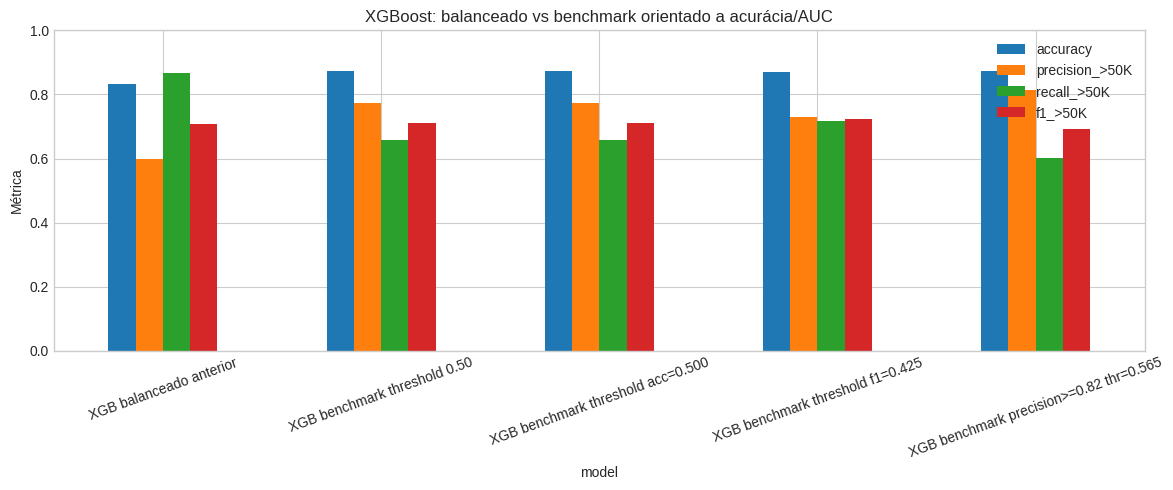

In [51]:

if XGBOOST_AVAILABLE:
    benchmark_compare_rows = []
    benchmark_compare_rows.append(metric_row('XGB balanceado anterior', xgb_metrics))
    benchmark_compare_rows.append({
        'model': 'XGB benchmark threshold 0.50',
        'accuracy': xgb_benchmark_default_metrics['accuracy'],
        'precision_>50K': xgb_benchmark_default_metrics['precision_>50K'],
        'recall_>50K': xgb_benchmark_default_metrics['recall_>50K'],
        'f1_>50K': xgb_benchmark_default_metrics['f1_>50K'],
    })
    benchmark_compare_rows.append({
        'model': f'XGB benchmark threshold acc={best_threshold_accuracy:.3f}',
        'accuracy': xgb_benchmark_acc_metrics['accuracy'],
        'precision_>50K': xgb_benchmark_acc_metrics['precision_>50K'],
        'recall_>50K': xgb_benchmark_acc_metrics['recall_>50K'],
        'f1_>50K': xgb_benchmark_acc_metrics['f1_>50K'],
    })
    benchmark_compare_rows.append({
        'model': f'XGB benchmark threshold f1={best_threshold_f1:.3f}',
        'accuracy': xgb_benchmark_f1_metrics['accuracy'],
        'precision_>50K': xgb_benchmark_f1_metrics['precision_>50K'],
        'recall_>50K': xgb_benchmark_f1_metrics['recall_>50K'],
        'f1_>50K': xgb_benchmark_f1_metrics['f1_>50K'],
    })
    if xgb_benchmark_precision_metrics is not None:
        benchmark_compare_rows.append({
            'model': f'XGB benchmark precision>=0.82 thr={best_threshold_precision_target:.3f}',
            'accuracy': xgb_benchmark_precision_metrics['accuracy'],
            'precision_>50K': xgb_benchmark_precision_metrics['precision_>50K'],
            'recall_>50K': xgb_benchmark_precision_metrics['recall_>50K'],
            'f1_>50K': xgb_benchmark_precision_metrics['f1_>50K'],
        })

    xgb_benchmark_comparison = pd.DataFrame(benchmark_compare_rows)
    display(xgb_benchmark_comparison)

    fig, ax = plt.subplots(figsize=(12, 5))
    xgb_benchmark_comparison.set_index('model')[['accuracy', 'precision_>50K', 'recall_>50K', 'f1_>50K']].plot(kind='bar', ax=ax)
    ax.set_title('XGBoost: balanceado vs benchmark orientado a acurácia/AUC')
    ax.set_ylabel('Métrica')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()


,feature,importance
0,marital_status,0.357978
1,relationship,0.199739
2,occupation,0.151597
3,native_country,0.064715
4,workclass,0.046446
5,education_num,0.045696
6,capital_gain,0.044448
7,capital_loss,0.021340
8,race,0.019859
9,sex,0.017794


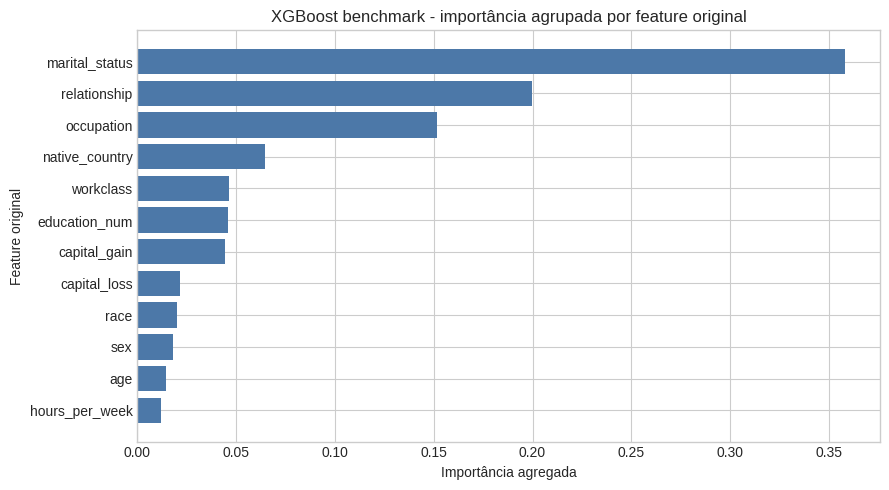

Taxa de predição >50K por sex - XGB benchmark threshold 0.50


,count,P(pred >50K) by sex
group,,
Male,10860,0.260405
Female,5421,0.080612


In [52]:

if XGBOOST_AVAILABLE:
    xgb_benchmark_importance = aggregate_importances(xgb_benchmark.feature_importances_, feature_groups)
    display(xgb_benchmark_importance)
    plot_top_importances(
        xgb_benchmark_importance,
        'XGBoost benchmark - importância agrupada por feature original',
    )

    print('Taxa de predição >50K por sex - XGB benchmark threshold 0.50')
    display(selection_rate_by_group(xgb_benchmark_default_pred, test_df['sex'], 'sex'))



### Leitura do XGBoost benchmark

O XGBoost balanceado anterior priorizava recall de `>50K`. A versão benchmark sem `scale_pos_weight` tende a aumentar acurácia e precision da classe positiva, mas reduz recall. Esse comportamento é esperado em bases desbalanceadas.

Para o relatório, é importante deixar claro qual métrica está sendo otimizada:

- Se o objetivo é benchmark de acurácia: usar o modelo benchmark sem `scale_pos_weight`.
- Se o objetivo é capturar mais casos `>50K`: usar `scale_pos_weight` ou threshold menor.
- Se o objetivo é fairness: comparar também taxas por `sex`/`race`, porque maior acurácia não implica menor viés.



## 16. Melhores features usando o XGBoost benchmark

Agora repetimos a análise de seleção de características usando o **XGBoost benchmark** da seção anterior, que atingiu a faixa de acurácia esperada (~87%).

Nesta seção usamos:

- Importância nativa do XGBoost agregada por feature original.
- Permutation importance agrupada por queda de F1.
- Ranking combinado.
- Comparação TP/FN usando o threshold benchmark escolhido.


,feature,base_f1,mean_drop_f1,std_drop_f1
0,marital_status,0.71073,0.119725,0.001494
1,capital_gain,0.71073,0.097453,0.002502
2,education_num,0.71073,0.076204,0.005480
3,age,0.71073,0.059957,0.003005
4,occupation,0.71073,0.052717,0.002151
5,hours_per_week,0.71073,0.030864,0.003043
6,capital_loss,0.71073,0.028491,0.000758
7,relationship,0.71073,0.026106,0.001837
8,sex,0.71073,0.010544,0.001185
9,workclass,0.71073,0.010541,0.001745


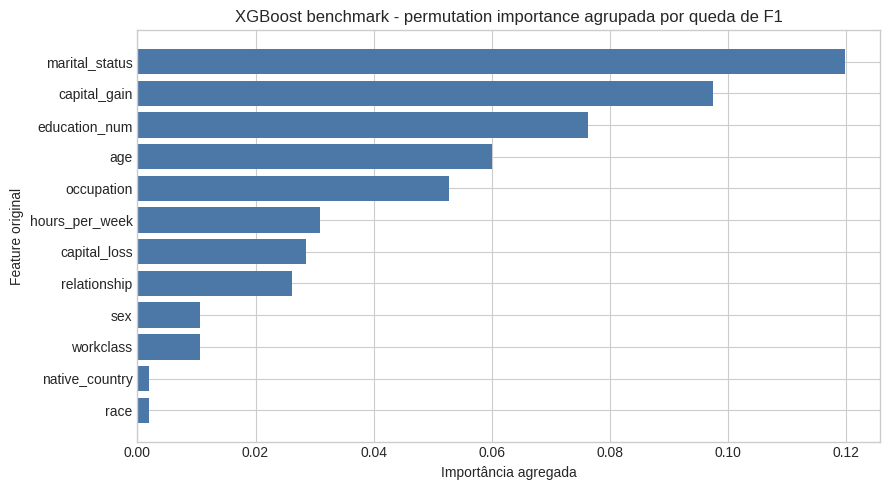

In [53]:

if XGBOOST_AVAILABLE:
    xgb_benchmark_perm_grouped = grouped_permutation_importance(
        xgb_benchmark,
        X_test,
        y_test,
        feature_groups,
        n_repeats=5,
        seed=SEED,
    )

    display(xgb_benchmark_perm_grouped)
    plot_top_importances(
        xgb_benchmark_perm_grouped.rename(columns={'mean_drop_f1': 'importance'})[['feature', 'importance']],
        'XGBoost benchmark - permutation importance agrupada por queda de F1',
    )


In [54]:

if XGBOOST_AVAILABLE:
    xgb_benchmark_feature_ranking = xgb_benchmark_importance.rename(
        columns={'importance': 'xgb_native_importance'}
    ).merge(
        xgb_benchmark_perm_grouped[['feature', 'mean_drop_f1']].rename(
            columns={'mean_drop_f1': 'xgb_permutation_drop_f1'}
        ),
        on='feature',
        how='outer',
    ).fillna(0)

    for col in ['xgb_native_importance', 'xgb_permutation_drop_f1']:
        xgb_benchmark_feature_ranking[col + '_rank'] = xgb_benchmark_feature_ranking[col].rank(
            ascending=False,
            method='min',
        )

    xgb_benchmark_feature_ranking['mean_rank'] = xgb_benchmark_feature_ranking[
        ['xgb_native_importance_rank', 'xgb_permutation_drop_f1_rank']
    ].mean(axis=1)

    xgb_benchmark_feature_ranking = xgb_benchmark_feature_ranking.sort_values(
        ['mean_rank', 'xgb_permutation_drop_f1'],
        ascending=[True, False],
    ).reset_index(drop=True)

    display(xgb_benchmark_feature_ranking)

    print('Principais candidatas pelo XGBoost benchmark:')
    for i, feature in enumerate(xgb_benchmark_feature_ranking.head(10)['feature'], 1):
        print(f'{i}. {feature}')


,feature,xgb_native_importance,xgb_permutation_drop_f1,xgb_native_importance_rank,xgb_permutation_drop_f1_rank,mean_rank
0,marital_status,0.357978,0.119725,1.0,1.0,1.0
1,occupation,0.151597,0.052717,3.0,5.0,4.0
2,capital_gain,0.044448,0.097453,7.0,2.0,4.5
3,education_num,0.045696,0.076204,6.0,3.0,4.5
4,relationship,0.199739,0.026106,2.0,8.0,5.0
5,age,0.014495,0.059957,11.0,4.0,7.5
6,capital_loss,0.021340,0.028491,8.0,7.0,7.5
7,workclass,0.046446,0.010541,5.0,10.0,7.5
8,native_country,0.064715,0.002040,4.0,11.0,7.5
9,hours_per_week,0.012122,0.030864,12.0,6.0,9.0


Principais candidatas pelo XGBoost benchmark:
1. marital_status
2. occupation
3. capital_gain
4. education_num
5. relationship
6. age
7. capital_loss
8. workclass
9. native_country
10. hours_per_week



### 16.1 Ranking explícito de importância do XGBoost SOTA/benchmark

As tabelas abaixo são o equivalente direto ao `encoded_importance` e `grouped_importance` usados antes, mas agora para o XGBoost benchmark/SOTA.

- `xgb_sota_encoded_importance`: importância por coluna codificada, incluindo cada categoria one-hot separadamente.
- `xgb_sota_grouped_importance`: importância agregada por feature original.
- `xgb_sota_permutation_importance`: ranking por queda de F1 ao permutar cada feature original.


In [ ]:

if XGBOOST_AVAILABLE:
    xgb_sota_encoded_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': xgb_benchmark.feature_importances_,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    xgb_sota_grouped_importance = aggregate_importances(
        xgb_benchmark.feature_importances_,
        feature_groups,
    )

    xgb_sota_permutation_importance = xgb_benchmark_perm_grouped.rename(
        columns={'mean_drop_f1': 'importance'}
    )[['feature', 'importance', 'std_drop_f1', 'base_f1']].sort_values(
        'importance', ascending=False
    ).reset_index(drop=True)

    print('XGBoost SOTA/benchmark - encoded importance por coluna')
    display(xgb_sota_encoded_importance.head(20))

    print('XGBoost SOTA/benchmark - grouped importance por feature original')
    display(xgb_sota_grouped_importance)

    print('XGBoost SOTA/benchmark - permutation importance por queda de F1')
    display(xgb_sota_permutation_importance)

    plot_top_importances(
        xgb_sota_grouped_importance,
        'XGBoost SOTA/benchmark - grouped importance',
    )
    plot_top_importances(
        xgb_sota_permutation_importance[['feature', 'importance']],
        'XGBoost SOTA/benchmark - permutation importance',
    )


In [55]:

if XGBOOST_AVAILABLE:
    xgb_benchmark_threshold_for_patterns = float(best_threshold_f1)
    xgb_benchmark_pattern_pred = (test_proba_benchmark >= xgb_benchmark_threshold_for_patterns).astype(int)

    print(f'Threshold usado para análise TP/FN do benchmark: {xgb_benchmark_threshold_for_patterns:.3f}')
    _ = evaluate_probability_model(
        y_test,
        test_proba_benchmark,
        threshold=xgb_benchmark_threshold_for_patterns,
        title='XGBoost benchmark usado para análise de padrões',
    )

    test_benchmark_patterns = test_df.copy()
    test_benchmark_patterns['is_high_income'] = (test_benchmark_patterns[TARGET_COL] == '>50K').astype(int)
    test_benchmark_patterns['prediction'] = xgb_benchmark_pattern_pred

    xgb_bench_tp = test_benchmark_patterns[
        (test_benchmark_patterns['is_high_income'] == 1) & (test_benchmark_patterns['prediction'] == 1)
    ].copy()
    xgb_bench_fn = test_benchmark_patterns[
        (test_benchmark_patterns['is_high_income'] == 1) & (test_benchmark_patterns['prediction'] == 0)
    ].copy()

    print(f'TP benchmark (>50K reconhecidos): {len(xgb_bench_tp)}')
    print(f'FN benchmark (>50K perdidos): {len(xgb_bench_fn)}')

    xgb_benchmark_numeric_comparison = pd.DataFrame({
        'TP_mean': xgb_bench_tp[NUMERIC_COLS].mean(),
        'FN_mean': xgb_bench_fn[NUMERIC_COLS].mean(),
        'difference_TP_minus_FN': xgb_bench_tp[NUMERIC_COLS].mean() - xgb_bench_fn[NUMERIC_COLS].mean(),
    }).round(2)

    display(xgb_benchmark_numeric_comparison)


Threshold usado para análise TP/FN do benchmark: 0.425
XGBoost benchmark usado para análise de padrões


,threshold,accuracy,balanced_accuracy,roc_auc,precision_>50K,recall_>50K,f1_>50K
0,0.425,0.86991,0.81669,0.927458,0.728692,0.715809,0.722193


              precision    recall  f1-score   support

       <=50K       0.91      0.92      0.92     12435
        >50K       0.73      0.72      0.72      3846

    accuracy                           0.87     16281
   macro avg       0.82      0.82      0.82     16281
weighted avg       0.87      0.87      0.87     16281



,pred <=50K,pred >50K
real <=50K,11410,1025
real >50K,1093,2753


TP benchmark (>50K reconhecidos): 2753
FN benchmark (>50K perdidos): 1093


,TP_mean,FN_mean,difference_TP_minus_FN
age,44.78,43.18,1.61
fnlwgt,191492.90,184198.02,7294.88
education_num,12.21,10.02,2.18
capital_gain,5718.47,79.18,5639.29
capital_loss,253.04,33.06,219.98
hours_per_week,46.21,43.40,2.81


In [56]:

if XGBOOST_AVAILABLE:
    for col in ['education', 'marital_status', 'occupation', 'relationship', 'sex', 'race', 'native_country']:
        print(f'Distribuição TP vs FN no XGBoost benchmark: {col}')
        display(compare_category_distribution(xgb_bench_tp, xgb_bench_fn, col))


Distribuição TP vs FN no XGBoost benchmark: education


,TP_share,FN_share,TP_minus_FN
education,,,
HS-grad,0.1333,0.4218,-0.2885
Bachelors,0.3414,0.1391,0.2024
Masters,0.1598,0.0549,0.1049
Prof-school,0.0683,0.0055,0.0628
Doctorate,0.0432,0.0055,0.0377
Some-college,0.1656,0.2013,-0.0356
11th,0.0033,0.0210,-0.0178
10th,0.0015,0.0192,-0.0178


Distribuição TP vs FN no XGBoost benchmark: marital_status


,TP_share,FN_share,TP_minus_FN
marital_status,,,
Married-civ-spouse,0.9110,0.7173,0.1937
Never-married,0.0363,0.1299,-0.0936
Divorced,0.0356,0.1006,-0.0650
Separated,0.0047,0.0183,-0.0136
Widowed,0.0076,0.0201,-0.0125
Married-spouse-absent,0.0040,0.0119,-0.0079
Married-AF-spouse,0.0007,0.0018,-0.0011


Distribuição TP vs FN no XGBoost benchmark: occupation


...

,TP_share,FN_share,TP_minus_FN
sex,,,
Female,0.1395,0.1885,-0.049
Male,0.8605,0.8115,0.049


Distribuição TP vs FN no XGBoost benchmark: race


,TP_share,FN_share,TP_minus_FN
race,,,
White,0.9168,0.8838,0.0330
Black,0.0396,0.0640,-0.0245
Other,0.0044,0.0119,-0.0075
Amer-Indian-Eskimo,0.0036,0.0082,-0.0046
Asian-Pac-Islander,0.0356,0.0320,0.0036


Distribuição TP vs FN no XGBoost benchmark: native_country


,TP_share,FN_share,TP_minus_FN
native_country,,,
United-States,0.9197,0.9067,0.0130
Portugal,0.0004,0.0064,-0.0060
Ireland,0.0004,0.0046,-0.0042
Mexico,0.0025,0.0064,-0.0039
England,0.0054,0.0018,0.0036
Japan,0.0029,0.0000,0.0029
Germany,0.0044,0.0018,0.0025
Iran,0.0004,0.0027,-0.0024


In [57]:

if XGBOOST_AVAILABLE:
    xgb_benchmark_pattern_summary = pd.DataFrame({
        'evidence': [
            'Ranking nativo XGBoost benchmark',
            'Permutation importance XGBoost benchmark',
            'TP vs FN numérico',
            'TP vs FN categórico',
        ],
        'interpretation': [
            'marital_status, relationship e occupation dominam a importância nativa, seguidos por education_num e capital_gain.',
            'A queda de F1 ao permutar revela quais atributos realmente sustentam a performance no teste.',
            'Casos >50K reconhecidos tendem a ter maior capital_gain, education_num, hours_per_week e capital_loss que os falsos negativos.',
            'Perfis Married-civ-spouse/Husband/Wife e ocupações Exec-managerial/Prof-specialty tendem a aparecer mais nos verdadeiros positivos.',
        ],
    })
    display(xgb_benchmark_pattern_summary)


,evidence,interpretation
0,Ranking nativo XGBoost benchmark,"marital_status, relationship e occupation domi..."
1,Permutation importance XGBoost benchmark,A queda de F1 ao permutar revela quais atribut...
2,TP vs FN numérico,Casos >50K reconhecidos tendem a ter maior cap...
3,TP vs FN categórico,Perfis Married-civ-spouse/Husband/Wife e ocupa...



### Como interpretar esta seção

A importância nativa do XGBoost mostra quais features são úteis para construir splits nas árvores. A permutation importance é mais próxima da pergunta: “quanto o desempenho cai se destruirmos a informação dessa feature?”.

Para seleção de features no relatório, dê mais peso ao consenso entre:

- Importância nativa do XGBoost benchmark.
- Permutation importance do XGBoost benchmark.
- Random Forest/permutation das seções anteriores.
- Permutation importance da MLP do notebook principal.
